In [ ]:
!pip install opencv-python
!pip install tqdm


In [1]:
#THIS IS HISTOGRAM 
# 1. Import required libraries

import cv2
import os
import csv
import numpy as np
from tqdm import tqdm


In [3]:
# 2. ColorDescriptor class for RGB histogram
class ColorDescriptor:
    def __init__(self, bins=(8, 8, 8)):
        self.bins = bins

    def describe(self, image):
        hist = cv2.calcHist([image], [0, 1, 2], None, self.bins, [0, 180, 0, 256, 0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        return hist.tolist()
        
# 3. Feature extraction and indexing
def extract_features(dataset_path, output_csv):
    cd = ColorDescriptor()
    with open(output_csv, "w", newline='') as f:
        writer = csv.writer(f)
        for image_name in tqdm(os.listdir(dataset_path), desc=f"Indexing {output_csv}"):
            image_path = os.path.join(dataset_path, image_name)
            image = cv2.imread(image_path)
            if image is None:
                continue
            features = cd.describe(image)
            writer.writerow([image_path] + features)
            
# 4. Chi-square distance
def chi2_distance(histA, histB, eps=1e-10):
    return 0.5 * np.sum([((a - b) ** 2) / (a + b + eps) for a, b in zip(histA, histB)])
    
# 5. Find best match for each Messidor image
def match_images(messidor_csv, ptrbynum_csv, output_file):
    matches = []
    
    # Load painters dataset into memory
    painters_data = []
    with open(ptrbynum_csv, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            painters_data.append((row[0], [float(x) for x in row[1:]]))
    
    with open(messidor_csv, 'r') as f:
        reader = csv.reader(f)
        for row in tqdm(reader, desc="Matching Messidor to Painters"):
            messidor_img = row[0]
            messidor_feat = [float(x) for x in row[1:]]
            
            best_score = float('inf')
            best_match = None
            
            for painter_img, painter_feat in painters_data:
                d = chi2_distance(messidor_feat, painter_feat)
                if d < best_score:
                    best_score = d
                    best_match = painter_img
                    
            matches.append((messidor_img, best_match))
    
    # Save matches
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Messidor Image', 'Painter Match'])
        writer.writerows(matches)



In [4]:
# 6. Run the full pipeline
messidor_dir = './messidor'
ptrbynum_dir = './painters_by_numbers'

extract_features(messidor_dir, 'messidor_histogram.csv')
extract_features(ptrbynum_dir, 'ptrbynum_histogram.csv')
match_images('messidor_histogram.csv', 'ptrbynum_histogram.csv', 'matches.csv')


Indexing ptrbynum_histogram.csv: 100%|██████████████████████████████████████████████| 8476/8476 [04:03<00:00, 34.77it/s]
Matching Messidor to Painters: 382it [02:35,  2.45it/s]


In [5]:
!pip install pandas


In [6]:
#THIS IS NEURAL STYLE TRANSFER

# 📦 Imports
import os
import cv2 as cv
import numpy as np
import torch
from torch import nn
from torchvision import models, transforms
from torch.optim import LBFGS
from torch.autograd import Variable
import pandas as pd

# 🧠 Constants
IMAGENET_MEAN_255 = [123.675, 116.28, 103.53]
IMAGENET_STD_NEUTRAL = [1, 1, 1]

In [7]:
# 📂 Dataset paths
matches_csv_path = 'matches.csv'
messidor_dir = './messidor'
painters_dir = './painters_by_numbers'
output_img_dir = './nst_output'

# 🔧 Utility Functions

def load_image(img_path, target_shape=None):
    if not os.path.exists(img_path):
        raise Exception(f'Path not found: {img_path}')
    img = cv.imread(img_path)[:, :, ::-1]  # BGR to RGB
    if target_shape is not None:
        if isinstance(target_shape, int) and target_shape != -1:
            h, w = img.shape[:2]
            new_h = target_shape
            new_w = int(w * (new_h / h))
            img = cv.resize(img, (new_w, new_h), interpolation=cv.INTER_CUBIC)
        else:
            img = cv.resize(img, (target_shape[1], target_shape[0]), interpolation=cv.INTER_CUBIC)
    img = img.astype(np.float32) / 255.0
    return img

In [8]:
def prepare_img(img_path, target_shape, device):
    img = load_image(img_path, target_shape=target_shape)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.mul(255)),
        transforms.Normalize(mean=IMAGENET_MEAN_255, std=IMAGENET_STD_NEUTRAL)
    ])
    img = transform(img).to(device).unsqueeze(0)
    return img

def save_image(img_tensor, path):
    img = img_tensor.squeeze().cpu().detach().numpy()
    img = np.moveaxis(img, 0, 2)
    img += np.array(IMAGENET_MEAN_255).reshape((1, 1, 3))
    img = np.clip(img, 0, 255).astype('uint8')
    cv.imwrite(path, img[:, :, ::-1])  # RGB to BGR

def gram_matrix(x, normalize=True):
    (b, ch, h, w) = x.size()
    features = x.view(b, ch, w * h)
    features_t = features.transpose(1, 2)
    gram = features.bmm(features_t)
    if normalize:
        gram /= ch * h * w
    return gram

def total_variation(y):
    return torch.sum(torch.abs(y[:, :, :, :-1] - y[:, :, :, 1:])) + torch.sum(torch.abs(y[:, :, :-1, :] - y[:, :, 1:, :]))


In [6]:
# 🧠 VGG Feature Extractor

class Vgg19(nn.Module):
    def __init__(self, requires_grad=False):
        super(Vgg19, self).__init__()
        vgg_pretrained_features = models.vgg19(weights='VGG19_Weights.DEFAULT').features
        self.slice = nn.ModuleList()
        self.layer_names = []
        count = 0
        for layer in vgg_pretrained_features:
            if isinstance(layer, nn.ReLU):
                layer = nn.ReLU(inplace=False)
            self.slice.append(layer)
            self.layer_names.append(f'layer_{count}')
            count += 1
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False
        self.content_feature_maps_index = 21
        self.style_feature_maps_indices = [0, 5, 10, 19, 28]

    def forward(self, x):
        features = []
        for i, layer in enumerate(self.slice):
            x = layer(x)
            if i in self.style_feature_maps_indices or i == self.content_feature_maps_index:
                features.append(x)
        return features

# 🎨 NST Core Logic

def build_loss(model, optimizing_img, targets, content_idx, style_indices, config):
    content_target, style_targets = targets
    features = model(optimizing_img)

    content_pred = features[style_indices.index(content_idx)]
    content_loss = nn.MSELoss()(content_pred.squeeze(), content_target)

    style_loss = 0.0
    for gt, pred in zip(style_targets, [gram_matrix(f) for i, f in enumerate(features) if i in style_indices]):
        style_loss += nn.MSELoss()(gt, pred)

    style_loss /= len(style_targets)
    tv_loss = total_variation(optimizing_img)

    total = config['content_weight'] * content_loss + config['style_weight'] * style_loss + config['tv_weight'] * tv_loss
    return total, content_loss, style_loss, tv_loss

def neural_style_transfer(config):
    content_img_path = os.path.join(config['content_images_dir'], config['content_img_name'])
    style_img_path = os.path.join(config['style_images_dir'], config['style_img_name'])

    out_img_name = f"{os.path.splitext(config['content_img_name'])[0]}_nst.jpg"
    dump_path = config['output_img_dir']
    os.makedirs(dump_path, exist_ok=True)

    # Assuming final_output_img is the result from NST
    # final_output_img = ...  # <-- Your NST output
    # final_output_img.save(os.path.join(dump_path, out_img_name))
    print(f"✅ Saved NST image to {os.path.join(dump_path, out_img_name)}")


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    content_img = prepare_img(content_img_path, config['height'], device)
    style_img = prepare_img(style_img_path, config['height'], device)
    init_img = content_img.clone()

    model = Vgg19().to(device).eval()

    # Extract features
    content_and_style_feats = model(content_img)
    style_feats = model(style_img)

    # Last feature is content, others are style
    content_target = content_and_style_feats[-1].squeeze()
    style_targets = [gram_matrix(feat) for feat in style_feats[:-1]]

    targets = (content_target, style_targets)
    optimizing_img = Variable(init_img.clone(), requires_grad=True)
    optimizer = LBFGS([optimizing_img], max_iter=300)

    iteration = [0]
    def closure():
        optimizer.zero_grad()
        feats = model(optimizing_img)
        content_feat = feats[-1]
        style_feats_out = feats[:-1]

        content_loss = nn.MSELoss()(content_feat.squeeze(), content_target)

        style_loss = 0.0
        for gt, pred in zip(style_targets, [gram_matrix(f) for f in style_feats_out]):
            style_loss += nn.MSELoss()(gt, pred)

        style_loss /= len(style_targets)
        tv_loss = total_variation(optimizing_img)

        total = config['content_weight'] * content_loss + config['style_weight'] * style_loss + config['tv_weight'] * tv_loss
        total.backward()

        if iteration[0] % 50 == 0:
            print(f"Iter {iteration[0]} | Total: {total.item():.2f} | Content: {content_loss.item():.2f} | Style: {style_loss.item():.2f} | TV: {tv_loss.item():.2f}")
        iteration[0] += 1
        return total

    optimizer.step(closure)

    final_img_path = os.path.join(dump_path, f"{os.path.splitext(config['content_img_name'])[0]}_nst.jpg")
    save_image(optimizing_img, final_img_path)
    print(f"✅ Saved to: {final_img_path}")


NameError: name 'nn' is not defined

In [10]:
# 🔁 Run NST for all matched pairs

matches = pd.read_csv(matches_csv_path)

for idx, row in matches.iterrows():
    content_img = os.path.basename(row['Messidor Image'])
    style_img = os.path.basename(row['Painter Match'])

    config = {
        'content_img_name': content_img,
        'style_img_name': style_img,
        'height': 400,
        'content_weight': 100000.0,
        'style_weight': 30000.0,
        'tv_weight': 1.0,
        'content_images_dir': messidor_dir,
        'style_images_dir': painters_dir,
        'output_img_dir': output_img_dir,
        'img_format': (4, '.jpg')
    }

    print(f"\n🎨 Transferring style from {style_img} to {content_img}...")
    neural_style_transfer(config)




🎨 Transferring style from 24645.jpg to c1.jpg...
✅ Saved NST image to ./nst_output/c1_nst.jpg
Iter 0 | Total: 17618100224.00 | Content: 0.00 | Style: 587190.00 | TV: 2399570.00
Iter 50 | Total: 797435328.00 | Content: 1967.22 | Style: 19470.40 | TV: 16601348.00
Iter 100 | Total: 464244352.00 | Content: 1360.45 | Style: 10355.96 | TV: 17520288.00
Iter 150 | Total: 359008928.00 | Content: 1109.58 | Style: 7654.16 | TV: 18426648.00
Iter 200 | Total: 306104928.00 | Content: 979.45 | Style: 6301.14 | TV: 19125998.00
Iter 250 | Total: 274945216.00 | Content: 895.56 | Style: 5528.61 | TV: 19530760.00
✅ Saved to: ./nst_output/c1_nst.jpg

🎨 Transferring style from 23994.jpg to c10.jpg...
✅ Saved NST image to ./nst_output/c10_nst.jpg
Iter 0 | Total: 3923289344.00 | Content: 0.00 | Style: 130693.41 | TV: 2486979.00
Iter 50 | Total: 416688320.00 | Content: 884.59 | Style: 10680.64 | TV: 7810411.00
Iter 100 | Total: 288247296.00 | Content: 638.03 | Style: 7196.85 | TV: 8538594.00
Iter 150 | Total:

In [11]:
import os
import random
import numpy as np
from PIL import Image
from torchvision import datasets
from torch.utils.data import Dataset

# === UTILS ===

class Utils:

    @staticmethod
    def load_fractal_images(fractal_img_dir):
        fractal_img_paths = [os.path.join(fractal_img_dir, fname)
                             for fname in os.listdir(fractal_img_dir)
                             if fname.endswith(('.png', '.jpg', '.jpeg'))]
        return [Image.open(path).convert('RGB').resize((256, 256)) for path in fractal_img_paths]

    @staticmethod
    def blend_images_with_resize(base_img, overlay_img, alpha=0.05):
        overlay_img_resized = overlay_img.resize(base_img.size)
        base_array = np.array(base_img, dtype=np.float32)
        overlay_array = np.array(overlay_img_resized, dtype=np.float32)
        assert base_array.shape == overlay_array.shape and len(base_array.shape) == 3
        blended_array = (1 - alpha) * base_array + alpha * overlay_array
        blended_array = np.clip(blended_array, 0, 255).astype(np.uint8)
        return Image.fromarray(blended_array)

    @staticmethod
    def combine_images(original_img, augmented_img, blend_width=20):
        width, height = original_img.size
        combine_choice = random.choice(['horizontal', 'vertical'])

        if combine_choice == 'vertical':
            mask = np.linspace(0, 1, blend_width).reshape(-1, 1)
            mask = np.tile(mask, (1, width))
            mask = np.vstack([
                np.zeros((height // 2 - blend_width // 2, width)),
                mask,
                np.ones((height // 2 - blend_width // 2 + blend_width % 2, width))
            ])
            mask = np.tile(mask[:, :, np.newaxis], (1, 1, 3))
        else:
            mask = np.linspace(0, 1, blend_width).reshape(1, -1)
            mask = np.tile(mask, (height, 1))
            mask = np.hstack([
                np.zeros((height, width // 2 - blend_width // 2)),
                mask,
                np.ones((height, width // 2 - blend_width // 2 + blend_width % 2))
            ])
            mask = np.tile(mask[:, :, np.newaxis], (1, 1, 3))

        original_array = np.array(original_img, dtype=np.float32) / 255.0
        augmented_array = np.array(augmented_img, dtype=np.float32) / 255.0

        blended_array = (1 - mask) * original_array + mask * augmented_array
        blended_array = np.clip(blended_array * 255, 0, 255).astype(np.uint8)

        return Image.fromarray(blended_array)

    @staticmethod
    def is_black_image(image):
        histogram = image.convert("L").histogram()
        return histogram[-1] > 0.9 * image.size[0] * image.size[1] and max(histogram[:-1]) < 0.1 * image.size[0] * image.size[1]



In [12]:
class DiffuseMix(Dataset):
    def __init__(self, messidor_dir, stylized_dir, fractal_imgs):
        self.messidor_dir = messidor_dir
        self.stylized_dir = stylized_dir
        self.fractal_imgs = fractal_imgs
        self.utils = Utils()
        self.image_pairs = self.match_image_pairs()
        self.augmented_images = self.generate_augmented_images()

    def match_image_pairs(self):
        messidor_images = [f for f in os.listdir(self.messidor_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        stylized_images = [f for f in os.listdir(self.stylized_dir) if f.endswith(('_nst.jpg'))]

        pairs = []
        for s_img in stylized_images:
            base_name = s_img.replace("_nst.jpg", ".jpg")
            if base_name in messidor_images:
                pairs.append((base_name, s_img))
            else:
                print(f"❌ No match found for: {s_img}")
        return pairs

    def generate_augmented_images(self):
        base_directory = './result'
        dirs = {
            'original_resized': os.path.join(base_directory, 'original_resized'),
            'stylized': os.path.join(base_directory, 'stylized'),
            'concatenated': os.path.join(base_directory, 'concatenated'),
            'blended': os.path.join(base_directory, 'blended'),
            'fractal': os.path.join(base_directory, 'fractal')
        }

        for dir_path in dirs.values():
            os.makedirs(dir_path, exist_ok=True)

        augmented_data = []

        print("\n🚀 Starting augmentation...\n")

        for base_name, style_name in self.image_pairs:
            base_filename = os.path.splitext(base_name)[0]

            original_img_path = os.path.join(self.messidor_dir, base_name)
            stylized_img_path = os.path.join(self.stylized_dir, style_name)

            original_img = Image.open(original_img_path).convert('RGB').resize((256, 256))
            stylized_img = Image.open(stylized_img_path).convert('RGB').resize((256, 256))

            if self.utils.is_black_image(stylized_img):
                print(f"⚠️ Skipping black stylized image: {stylized_img_path}")
                continue

            # Save original
            original_img.save(os.path.join(dirs['original_resized'], base_name))

            # Save stylized
            stylized_img.save(os.path.join(dirs['stylized'], style_name))

            # Concatenate
            concatenated = self.utils.combine_images(original_img, stylized_img)
            concat_path = os.path.join(dirs['concatenated'], f"{base_filename}_concat.jpg")
            concatenated.save(concat_path)

            # Fractal
            fractal_img = random.choice(self.fractal_imgs)
            fractal_path = os.path.join(dirs['fractal'], f"{base_filename}_fractal.jpg")
            fractal_img.save(fractal_path)

            # Blend
            blended = self.utils.blend_images_with_resize(concatenated, fractal_img)
            blended_path = os.path.join(dirs['blended'], f"{base_filename}_blended.jpg")
            blended.save(blended_path)

            augmented_data.append((blended, base_filename))

        print("\n✅ Augmentation complete!\n")
        return augmented_data

    def __len__(self):
        return len(self.augmented_images)

    def __getitem__(self, idx):
        return self.augmented_images[idx]


In [13]:
# Paths
messidor_path = './messidor'           
stylized_path = './nst_output'            
fractal_dir = './fractal_images'         

# Load
fractal_imgs = Utils.load_fractal_images(fractal_dir)

# No class structure needed now
diffusemix_dataset = DiffuseMix(
    messidor_dir=messidor_path,
    stylized_dir=stylized_path,
    fractal_imgs=fractal_imgs
)

# Save augmented images to disk
os.makedirs("augmented_images", exist_ok=True)
for idx, (image, name) in enumerate(diffusemix_dataset):
    path = f"augmented_images/{name}.jpg"
    image.save(path)
    print(f"✅ Saved: {path}")



🚀 Starting augmentation...


✅ Augmentation complete!

✅ Saved: augmented_images/c100.jpg
✅ Saved: augmented_images/c101.jpg
✅ Saved: augmented_images/c102.jpg
✅ Saved: augmented_images/c103.jpg
✅ Saved: augmented_images/c104.jpg
✅ Saved: augmented_images/c105.jpg
✅ Saved: augmented_images/c106.jpg
✅ Saved: augmented_images/c107.jpg
✅ Saved: augmented_images/c108.jpg
✅ Saved: augmented_images/c109.jpg
✅ Saved: augmented_images/c10.jpg
✅ Saved: augmented_images/c110.jpg
✅ Saved: augmented_images/c111.jpg
✅ Saved: augmented_images/c112.jpg
✅ Saved: augmented_images/c113.jpg
✅ Saved: augmented_images/c114.jpg
✅ Saved: augmented_images/c115.jpg
✅ Saved: augmented_images/c116.jpg
✅ Saved: augmented_images/c117.jpg
✅ Saved: augmented_images/c118.jpg
✅ Saved: augmented_images/c119.jpg
✅ Saved: augmented_images/c11.jpg
✅ Saved: augmented_images/c120.jpg
✅ Saved: augmented_images/c121.jpg
✅ Saved: augmented_images/c122.jpg
✅ Saved: augmented_images/c123.jpg
✅ Saved: augmented_images/c124.jpg
✅

✅ Saved: augmented_images/c338.jpg
✅ Saved: augmented_images/c339.jpg
✅ Saved: augmented_images/c33.jpg
✅ Saved: augmented_images/c340.jpg
✅ Saved: augmented_images/c341.jpg
✅ Saved: augmented_images/c342.jpg
✅ Saved: augmented_images/c343.jpg
✅ Saved: augmented_images/c344.jpg
✅ Saved: augmented_images/c345.jpg
✅ Saved: augmented_images/c346.jpg
✅ Saved: augmented_images/c347.jpg
✅ Saved: augmented_images/c348.jpg
✅ Saved: augmented_images/c349.jpg
✅ Saved: augmented_images/c34.jpg
✅ Saved: augmented_images/c350.jpg
✅ Saved: augmented_images/c351.jpg
✅ Saved: augmented_images/c352.jpg
✅ Saved: augmented_images/c353.jpg
✅ Saved: augmented_images/c354.jpg
✅ Saved: augmented_images/c355.jpg
✅ Saved: augmented_images/c356.jpg
✅ Saved: augmented_images/c357.jpg
✅ Saved: augmented_images/c358.jpg
✅ Saved: augmented_images/c359.jpg
✅ Saved: augmented_images/c35.jpg
✅ Saved: augmented_images/c360.jpg
✅ Saved: augmented_images/c361.jpg
✅ Saved: augmented_images/c362.jpg
✅ Saved: augmented_imag

In [1]:
!pip install torch torchvision --quiet

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.6.0+cu124
True


In [6]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall --quiet


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2025.10.0 requires fsspec==2025.10.0, but you have fsspec 2025.12.0 which is incompatible.
sip 6.12.0 requires setuptools>=75.8.1, but you have setuptools 70.2.0 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.8 which is incompatible.


In [1]:
import cv2
import os
from tqdm import tqdm

# Paths
messidor_dir = './messidor'
dump_path = './rot_output'
os.makedirs(dump_path, exist_ok=True)

# Rotation angles
rotation_angles = [90]

def rotate_image(img, angle):
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

# Rotate and save images
for filename in tqdm(os.listdir(messidor_dir), desc="Applying rotation"):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        continue

    img_path = os.path.join(messidor_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read image: {filename}")
        continue

    base_name = os.path.splitext(filename)[0]
    
    for angle in rotation_angles:
        rotated = rotate_image(img, angle)
        final_img_path = os.path.join(dump_path, f"{base_name}_rot{angle}.jpg")
        cv2.imwrite(final_img_path, rotated)
        print(f"✅ Saved to: {final_img_path}")


Applying rotation:   3%|█▉                                                            | 12/383 [00:00<00:06, 56.86it/s]

✅ Saved to: ./rot_output\c1_rot90.jpg
✅ Saved to: ./rot_output\c10_rot90.jpg
✅ Saved to: ./rot_output\c100_rot90.jpg
✅ Saved to: ./rot_output\c101_rot90.jpg
✅ Saved to: ./rot_output\c102_rot90.jpg
✅ Saved to: ./rot_output\c103_rot90.jpg
✅ Saved to: ./rot_output\c104_rot90.jpg
✅ Saved to: ./rot_output\c105_rot90.jpg
✅ Saved to: ./rot_output\c106_rot90.jpg
✅ Saved to: ./rot_output\c107_rot90.jpg
✅ Saved to: ./rot_output\c108_rot90.jpg
✅ Saved to: ./rot_output\c109_rot90.jpg


Applying rotation:   9%|█████▎                                                        | 33/383 [00:00<00:04, 86.20it/s]

✅ Saved to: ./rot_output\c11_rot90.jpg
✅ Saved to: ./rot_output\c110_rot90.jpg
✅ Saved to: ./rot_output\c111_rot90.jpg
✅ Saved to: ./rot_output\c112_rot90.jpg
✅ Saved to: ./rot_output\c113_rot90.jpg
✅ Saved to: ./rot_output\c114_rot90.jpg
✅ Saved to: ./rot_output\c115_rot90.jpg
✅ Saved to: ./rot_output\c116_rot90.jpg
✅ Saved to: ./rot_output\c117_rot90.jpg
✅ Saved to: ./rot_output\c118_rot90.jpg
✅ Saved to: ./rot_output\c119_rot90.jpg
✅ Saved to: ./rot_output\c12_rot90.jpg
✅ Saved to: ./rot_output\c120_rot90.jpg
✅ Saved to: ./rot_output\c121_rot90.jpg
✅ Saved to: ./rot_output\c122_rot90.jpg
✅ Saved to: ./rot_output\c123_rot90.jpg
✅ Saved to: ./rot_output\c124_rot90.jpg
✅ Saved to: ./rot_output\c125_rot90.jpg
✅ Saved to: ./rot_output\c126_rot90.jpg
✅ Saved to: ./rot_output\c127_rot90.jpg


Applying rotation:  11%|███████                                                       | 44/383 [00:00<00:03, 90.23it/s]

...

✅ Saved to: ./rot_output\c71_rot90.jpg
✅ Saved to: ./rot_output\c72_rot90.jpg
✅ Saved to: ./rot_output\c73_rot90.jpg
✅ Saved to: ./rot_output\c74_rot90.jpg
✅ Saved to: ./rot_output\c75_rot90.jpg
✅ Saved to: ./rot_output\c76_rot90.jpg
✅ Saved to: ./rot_output\c77_rot90.jpg
✅ Saved to: ./rot_output\c78_rot90.jpg
✅ Saved to: ./rot_output\c79_rot90.jpg
✅ Saved to: ./rot_output\c8_rot90.jpg
✅ Saved to: ./rot_output\c80_rot90.jpg
✅ Saved to: ./rot_output\c81_rot90.jpg
✅ Saved to: ./rot_output\c82_rot90.jpg
✅ Saved to: ./rot_output\c83_rot90.jpg


Applying rotation:  98%|███████████████████████████████████████████████████████████▌ | 374/383 [00:04<00:00, 75.50it/s]

✅ Saved to: ./rot_output\c84_rot90.jpg
✅ Saved to: ./rot_output\c85_rot90.jpg
✅ Saved to: ./rot_output\c86_rot90.jpg
✅ Saved to: ./rot_output\c87_rot90.jpg
✅ Saved to: ./rot_output\c88_rot90.jpg
✅ Saved to: ./rot_output\c89_rot90.jpg
✅ Saved to: ./rot_output\c9_rot90.jpg
✅ Saved to: ./rot_output\c90_rot90.jpg
✅ Saved to: ./rot_output\c91_rot90.jpg
✅ Saved to: ./rot_output\c92_rot90.jpg
✅ Saved to: ./rot_output\c93_rot90.jpg
✅ Saved to: ./rot_output\c94_rot90.jpg


Applying rotation: 100%|█████████████████████████████████████████████████████████████| 383/383 [00:04<00:00, 77.45it/s]

✅ Saved to: ./rot_output\c95_rot90.jpg
✅ Saved to: ./rot_output\c96_rot90.jpg
✅ Saved to: ./rot_output\c97_rot90.jpg
✅ Saved to: ./rot_output\c98_rot90.jpg
✅ Saved to: ./rot_output\c99_rot90.jpg


In [11]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TripletDataset(Dataset):
    def __init__(self, positive_dir, anchor_dir, negative_dir, transform=None, neg_seed=42):
        self.positive_dir = positive_dir
        self.anchor_dir = anchor_dir
        self.negative_dir = negative_dir
        self.transform = transform

        # Normalize paths for Windows compatibility
        self.positive_dir = os.path.normpath(positive_dir)
        self.anchor_dir = os.path.normpath(anchor_dir)
        self.negative_dir = os.path.normpath(negative_dir)

        # Validate directories
        for dir_path, name in [(positive_dir, 'positive'), 
                              (anchor_dir, 'anchor'),
                              (negative_dir, 'negative')]:
            if not os.path.exists(dir_path):
                raise FileNotFoundError(f"{name} directory not found: {dir_path}")

        # Suffix mapping with path component checking
        suffix_mapping = {
            'rot_output': '_rot90.jpg',
            'concatenated': '_concat.jpg',
            'nst_output': '_nst.jpg',
            'blended': '_blended.jpg'
        }

        # Find matching suffix
        suffix = None
        for key in suffix_mapping:
            if key in self.positive_dir.split(os.sep):
                suffix = suffix_mapping[key]
                break

        if suffix is None:
            raise ValueError(f"Could not determine suffix for directory: {positive_dir}")

        # Load filenames with verification
        self.positive_images = []
        self.anchor_images = []

        for f in sorted(os.listdir(positive_dir)):
            if f.endswith(suffix):
                anchor_name = f.replace(suffix, '.jpg')
                pos_path = os.path.join(positive_dir, f)
                anc_path = os.path.join(anchor_dir, anchor_name)

                try:
                    with Image.open(pos_path) as img:
                        img.verify()
                    with Image.open(anc_path) as img:
                        img.verify()

                    self.positive_images.append(f)
                    self.anchor_images.append(anchor_name)
                except (IOError, OSError) as e:
                    print(f"Skipping corrupt pair: {f} - Error: {e}")

        # Load negative images with verification
        self.negative_images = []
        for f in sorted(os.listdir(negative_dir)):
            if f.endswith('.png'):
                neg_path = os.path.join(negative_dir, f)
                try:
                    with Image.open(neg_path) as img:
                        img.verify()
                    self.negative_images.append(f)
                except (IOError, OSError) as e:
                    print(f"Skipping corrupt negative: {f} - Error: {e}")

        # Final validation
        if not self.positive_images:
            raise RuntimeError(f"No valid positive images found in {positive_dir}")
        if not self.negative_images:
            raise RuntimeError(f"No valid negative images found in {negative_dir}")

        # Pre-assign a fixed negative for each index using a seeded RNG.
        # This ensures every branch gets the SAME negative for the same idx,
        # making the triplet composition identical across augmentation techniques.
        rng = np.random.RandomState(neg_seed)
        self.neg_indices = rng.randint(0, len(self.negative_images), size=len(self.positive_images))

    def __len__(self):
        return len(self.positive_images)

    def __getitem__(self, idx):
        # Get image paths
        positive_img_path = os.path.join(self.positive_dir, self.positive_images[idx])
        anchor_img_path = os.path.join(self.anchor_dir, self.anchor_images[idx])
        # Use the pre-assigned negative instead of random selection
        negative_img_path = os.path.join(self.negative_dir, self.negative_images[self.neg_indices[idx]])
        
        try:
            anchor = Image.open(anchor_img_path).convert('RGB')
            positive = Image.open(positive_img_path).convert('RGB')
            negative = Image.open(negative_img_path).convert('RGB')
        except Exception as e:
            raise RuntimeError(f"Error loading images: {e}")

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Initialize datasets — all share the same neg_seed so negatives are identical per index
datasets = {
    "NST": TripletDataset('./nst_output', './messidor', './negative_images', transform, neg_seed=42),
    "Concat": TripletDataset('./result/concatenated', './messidor', './negative_images', transform, neg_seed=42),
    "Rotation": TripletDataset('./rot_output', './messidor', './negative_images', transform, neg_seed=42),
    "NST+FB": TripletDataset('./result/blended', './messidor', './negative_images', transform, neg_seed=42),
}

# DataLoaders are created inside the training loop with a fresh generator each time
# to ensure identical batch ordering across branches (see next cell).

In [12]:
from torchvision.models import resnet18
from torch import nn
import torch.nn.functional as F

class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)  # Embedding size 128
        
    def forward(self, x):
        x = self.resnet(x)
        return F.normalize(x, p=2, dim=1)  # L2-normalized embeddings

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

In [13]:
import torch
import copy
import random
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
TOTAL_EPOCHS = 125
CHECKPOINT_EVERY = 25  # Save model state at every 25 epochs

def seed_everything(seed):
    """Reset all RNGs so each branch starts from the same state."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def worker_init_fn(worker_id):
    """Ensure each DataLoader worker has a reproducible seed."""
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

def make_loader(dataset, batch_size=16, seed=42):
    """Create a DataLoader with a fresh seeded generator for deterministic shuffle order."""
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=g,
        worker_init_fn=worker_init_fn,
    )

def train_with_checkpoints(model, loader, optimizer, loss_fn, total_epochs, checkpoint_every):
    """Train once, save model snapshots at regular intervals."""
    model.train()
    checkpoints = {}
    
    for epoch in range(1, total_epochs + 1):
        total_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs}")
        
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()
            anchor_emb = model(anchor)
            positive_emb = model(positive)
            negative_emb = model(negative)

            loss = loss_fn(anchor_emb, positive_emb, negative_emb)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
        
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch} - Avg Loss: {avg_loss:.4f}")
        
        # Save a deep copy of the model at each checkpoint
        if epoch % checkpoint_every == 0:
            checkpoints[epoch] = copy.deepcopy(model.state_dict())
            print(f"  >> Checkpoint saved at epoch {epoch}")
    
    return checkpoints

# Train all branches — single continuous run with checkpoints
all_checkpoints = {}  # {branch_name: {epoch: state_dict}}
models = {}

for name, ds in datasets.items():
    print(f"\n{'='*60}")
    print(f"=== Training {name} Model ({TOTAL_EPOCHS} epochs) ===")
    print(f"{'='*60}")
    
    # Reset all random state
    seed_everything(SEED)
    
    # Create DataLoader
    loader = make_loader(ds, batch_size=16, seed=SEED)
    
    # Build model with identical init weights
    model = EmbeddingNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    loss_fn = TripletLoss(margin=1.0)
    
    # Train once continuously, saving checkpoints
    checkpoints = train_with_checkpoints(model, loader, optimizer, loss_fn, TOTAL_EPOCHS, CHECKPOINT_EVERY)
    
    all_checkpoints[name] = checkpoints
    models[name] = model  # Final model (at TOTAL_EPOCHS)

print(f"\n{'='*60}")
print("Training complete! Checkpoints saved at epochs: " + 
      ", ".join(str(e) for e in range(CHECKPOINT_EVERY, TOTAL_EPOCHS+1, CHECKPOINT_EVERY)))
print(f"{'='*60}")

Using device: cuda

=== Training NST Model (125 epochs) ===


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/125: 100%|█████████████████████████████████████████████████████████| 24/24 [00:24<00:00,  1.00s/it, loss=0.412]


Epoch 1 - Avg Loss: 0.5223


Epoch 2/125: 100%|█████████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.01it/s, loss=0.127]


Epoch 2 - Avg Loss: 0.1681


...

Epoch 123 - Avg Loss: 0.0026


Epoch 124/125: 100%|███████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.00it/s, loss=0.028]


Epoch 124 - Avg Loss: 0.0034


Epoch 125/125: 100%|███████████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.00it/s, loss=0]

Epoch 125 - Avg Loss: 0.0018
  >> Checkpoint saved at epoch 125

Training complete! Checkpoints saved at epochs: 25, 50, 75, 100, 125


In [14]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def get_embeddings(model, dataloader, device):
    """Extract embeddings from a trained model."""
    model.eval()
    embeddings = []
    with torch.no_grad():
        for anchor, _, _ in dataloader:
            anchor = anchor.to(device)
            output = model(anchor)
            embeddings.append(output.cpu())
    return torch.cat(embeddings, dim=0).numpy()

def evaluate_checkpoints(all_checkpoints, datasets, device, n_clusters=2):
    """Evaluate silhouette scores at every checkpoint for all branches."""
    
    # Score table: {branch_name: {epoch: score}}
    score_table = {}
    epoch_list = sorted(next(iter(all_checkpoints.values())).keys())
    
    for name, checkpoints in all_checkpoints.items():
        print(f"Evaluating {name}...")
        score_table[name] = {}
        loader = make_loader(datasets[name], batch_size=16, seed=SEED)
        
        for epoch, state_dict in sorted(checkpoints.items()):
            # Load checkpoint weights into a fresh model
            model = EmbeddingNet().to(device)
            model.load_state_dict(state_dict)
            
            # Get embeddings
            embeddings = get_embeddings(model, loader, device)
            
            # Cluster and score on 128-dim embeddings
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(embeddings)
            score = silhouette_score(embeddings, labels)
            
            score_table[name][epoch] = score
            print(f"  Epoch {epoch}: {score:.4f}")
    
    # ==========================================
    # LEARNING CURVE PLOT
    # ==========================================
    plt.figure(figsize=(10, 6))
    colors = {'NST': '#1f77b4', 'Concat': '#ff7f0e', 'Rotation': '#2ca02c', 'NST+FB': '#d62728'}
    markers = {'NST': 'o', 'Concat': 's', 'Rotation': '^', 'NST+FB': 'D'}
    
    for name, scores in score_table.items():
        epochs = sorted(scores.keys())
        values = [scores[e] for e in epochs]
        plt.plot(epochs, values, 
                marker=markers.get(name, 'o'), 
                color=colors.get(name, 'black'),
                linewidth=2, markersize=8, label=name)
    
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Silhouette Score (128-dim)", fontsize=12)
    plt.title("Learning Curve — Silhouette Score vs Training Epochs\n(Single continuous training run per branch)", fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(epoch_list)
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # SUMMARY TABLE
    # ==========================================
    print("\n" + "="*70)
    print(f"{'Method':<12}", end="")
    for e in epoch_list:
        print(f"{'Epoch '+str(e):>12}", end="")
    print(f"{'Best':>12}  {'Best Epoch':>12}")
    print("="*70)
    
    for name, scores in score_table.items():
        print(f"{name:<12}", end="")
        best_score = -1
        best_epoch = -1
        for e in epoch_list:
            s = scores[e]
            if s > best_score:
                best_score = s
                best_epoch = e
            print(f"{s:>12.4f}", end="")
        print(f"{best_score:>12.4f}  {'Epoch '+str(best_epoch):>12}")
    print("="*70)
    
    # ==========================================
    # t-SNE VISUALIZATION AT BEST EPOCH PER BRANCH
    # ==========================================
    n = len(score_table)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    
    for idx, (name, scores) in enumerate(score_table.items()):
        best_epoch = max(scores, key=scores.get)
        best_score = scores[best_epoch]
        
        # Load best checkpoint
        model = EmbeddingNet().to(device)
        model.load_state_dict(all_checkpoints[name][best_epoch])
        loader = make_loader(datasets[name], batch_size=16, seed=SEED)
        embeddings = get_embeddings(model, loader, device)
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        reduced = tsne.fit_transform(embeddings)
        
        ax = axes[idx] if n > 1 else axes
        for label in range(n_clusters):
            mask = labels == label
            ax.scatter(reduced[mask, 0], reduced[mask, 1],
                      label=f'Cluster {label}', alpha=0.7, s=30)
        ax.set_title(f"{name} (Best: Epoch {best_epoch})\nSilhouette: {best_score:.4f}")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend()
        ax.grid(True)
    
    plt.suptitle("t-SNE Visualization at Best Epoch per Augmentation", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return score_table

Evaluating NST...


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 25: 0.1943


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 50: 0.2201


...

  Epoch 75: 0.1457


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 100: 0.1470


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  Epoch 125: 0.1573


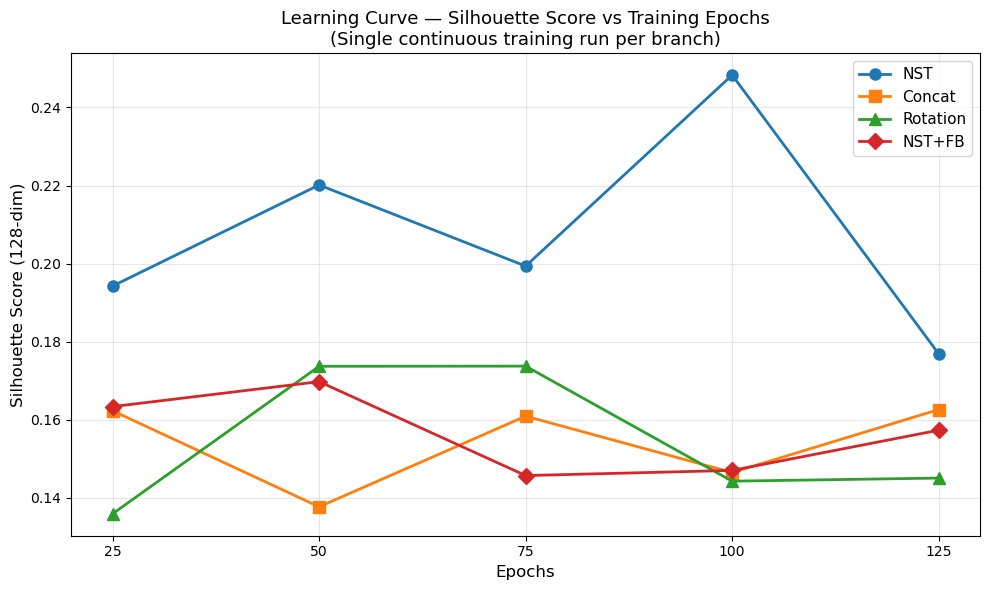


Method          Epoch 25    Epoch 50    Epoch 75   Epoch 100   Epoch 125        Best    Best Epoch
NST               0.1943      0.2201      0.1994      0.2483      0.1769      0.2483     Epoch 100
Concat            0.1623      0.1377      0.1609      0.1465      0.1626      0.1626     Epoch 125
Rotation          0.1359      0.1737      0.1737      0.1443      0.1451      0.1737      Epoch 75
NST+FB            0.1634      0.1698      0.1457      0.1470      0.1573      0.1698      Epoch 50


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarnin

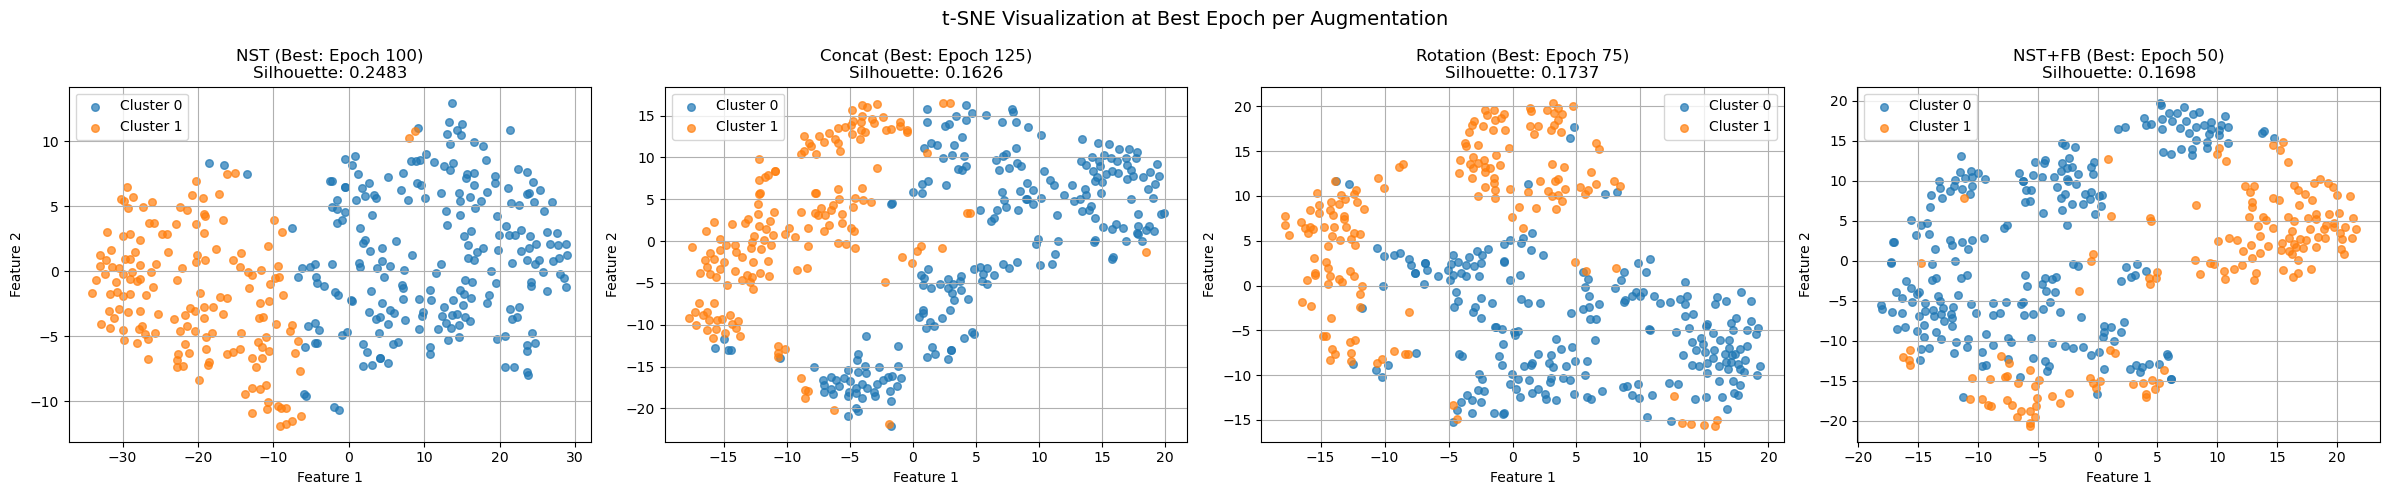

In [15]:
# Evaluate all checkpoints and plot learning curves
score_table = evaluate_checkpoints(all_checkpoints, datasets, device, n_clusters=2)

In [16]:
# Print silhouette scores from the results (already computed above)
for name, r in results.items():
    print(f"Silhouette Score for {name}: {r['score']:.4f}")

Silhouette Score for NST: 0.2385
Silhouette Score for Concat: 0.1877
Silhouette Score for Rotation: 0.1404
Silhouette Score for NST+FB: 0.2020


## Phase 1: Blending Ratio Ablation Study
Regenerate blended images at multiple alpha values using the existing concatenated + fractal images, then train and evaluate each variant.

In [17]:
import os
import numpy as np
from PIL import Image

# Alpha values to test
alphas = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Source directories (already generated by the augmentation pipeline)
concat_dir = './result/concatenated'
fractal_dir = './result/fractal'

def blend_images(base_img, overlay_img, alpha):
    """Blend base and overlay images with given alpha ratio."""
    overlay_resized = overlay_img.resize(base_img.size)
    base_array = np.array(base_img, dtype=np.float32)
    overlay_array = np.array(overlay_resized, dtype=np.float32)
    blended = (1 - alpha) * base_array + alpha * overlay_array
    blended = np.clip(blended, 0, 255).astype(np.uint8)
    return Image.fromarray(blended)

# Get list of concatenated images
concat_files = sorted([f for f in os.listdir(concat_dir) if f.endswith('_concat.jpg')])
print(f"Found {len(concat_files)} concatenated images")

# Generate blended images for each alpha
for alpha in alphas:
    alpha_str = f"{int(alpha*100):03d}"  # e.g., 005, 010, 015
    output_dir = f'./result/blended_{alpha_str}'
    os.makedirs(output_dir, exist_ok=True)
    
    count = 0
    for concat_file in concat_files:
        base_name = concat_file.replace('_concat.jpg', '')
        fractal_file = f"{base_name}_fractal.jpg"
        
        concat_path = os.path.join(concat_dir, concat_file)
        fractal_path = os.path.join(fractal_dir, fractal_file)
        
        if not os.path.exists(fractal_path):
            continue
        
        concat_img = Image.open(concat_path).convert('RGB')
        fractal_img = Image.open(fractal_path).convert('RGB')
        
        blended = blend_images(concat_img, fractal_img, alpha)
        
        # Save with _blended.jpg suffix (same convention as original)
        output_path = os.path.join(output_dir, f"{base_name}_blended.jpg")
        blended.save(output_path)
        count += 1
    
    print(f"  alpha={alpha:.2f} -> {output_dir} ({count} images)")

print("\nAll blended variants generated!")

Found 382 concatenated images
  alpha=0.05 -> ./result/blended_005 (382 images)
  alpha=0.10 -> ./result/blended_010 (382 images)
  alpha=0.15 -> ./result/blended_015 (382 images)
  alpha=0.20 -> ./result/blended_020 (382 images)
  alpha=0.25 -> ./result/blended_025 (382 images)
  alpha=0.30 -> ./result/blended_030 (382 images)

All blended variants generated!


In [18]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TripletDatasetAlpha(Dataset):
    """TripletDataset for ablation study — accepts any blended_XXX folder."""
    def __init__(self, positive_dir, anchor_dir, negative_dir, transform=None, neg_seed=42):
        self.positive_dir = os.path.normpath(positive_dir)
        self.anchor_dir = os.path.normpath(anchor_dir)
        self.negative_dir = os.path.normpath(negative_dir)
        self.transform = transform

        # All alpha folders use _blended.jpg suffix
        suffix = '_blended.jpg'

        # Load and verify positive-anchor pairs
        self.positive_images = []
        self.anchor_images = []
        for f in sorted(os.listdir(self.positive_dir)):
            if f.endswith(suffix):
                anchor_name = f.replace(suffix, '.jpg')
                pos_path = os.path.join(self.positive_dir, f)
                anc_path = os.path.join(self.anchor_dir, anchor_name)
                try:
                    with Image.open(pos_path) as img:
                        img.verify()
                    with Image.open(anc_path) as img:
                        img.verify()
                    self.positive_images.append(f)
                    self.anchor_images.append(anchor_name)
                except (IOError, OSError) as e:
                    print(f"Skipping: {f} - {e}")

        # Load negative images
        self.negative_images = []
        for f in sorted(os.listdir(self.negative_dir)):
            if f.endswith('.png'):
                try:
                    with Image.open(os.path.join(self.negative_dir, f)) as img:
                        img.verify()
                    self.negative_images.append(f)
                except (IOError, OSError):
                    pass

        if not self.positive_images:
            raise RuntimeError(f"No valid images in {positive_dir}")
        if not self.negative_images:
            raise RuntimeError(f"No valid negatives in {negative_dir}")

        # Fixed negative assignment (same across all alphas)
        rng = np.random.RandomState(neg_seed)
        self.neg_indices = rng.randint(0, len(self.negative_images), size=len(self.positive_images))
        print(f"  {positive_dir}: {len(self.positive_images)} pairs loaded")

    def __len__(self):
        return len(self.positive_images)

    def __getitem__(self, idx):
        pos_path = os.path.join(self.positive_dir, self.positive_images[idx])
        anc_path = os.path.join(self.anchor_dir, self.anchor_images[idx])
        neg_path = os.path.join(self.negative_dir, self.negative_images[self.neg_indices[idx]])
        
        anchor = Image.open(anc_path).convert('RGB')
        positive = Image.open(pos_path).convert('RGB')
        negative = Image.open(neg_path).convert('RGB')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Phase 1: Create datasets for all 6 alpha variants
print("Loading Phase 1 datasets (ablation)...\n")
ablation_datasets = {}
for alpha in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    alpha_str = f"{int(alpha*100):03d}"
    name = f"α={alpha:.2f}"
    ablation_datasets[name] = TripletDatasetAlpha(
        f'./result/blended_{alpha_str}', './messidor', './negative_images',
        transform, neg_seed=42
    )

print(f"\n{len(ablation_datasets)} ablation datasets loaded.")

Loading Phase 1 datasets (ablation)...

  ./result/blended_005: 382 pairs loaded
  ./result/blended_010: 382 pairs loaded
  ./result/blended_015: 382 pairs loaded
  ./result/blended_020: 382 pairs loaded
  ./result/blended_025: 382 pairs loaded
  ./result/blended_030: 382 pairs loaded

6 ablation datasets loaded.


In [19]:
import torch
import copy
import random
import numpy as np
from tqdm import tqdm
from torchvision.models import resnet18
from torch import nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
TOTAL_EPOCHS = 125
CHECKPOINT_EVERY = 25

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

def make_loader(dataset, batch_size=16, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=torch.cuda.is_available(),
        generator=g, worker_init_fn=worker_init_fn,
    )

class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)
    def forward(self, x):
        return F.normalize(self.resnet(x), p=2, dim=1)

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        return F.relu(pos_dist - neg_dist + self.margin).mean()

def train_with_checkpoints(model, loader, optimizer, loss_fn, total_epochs, checkpoint_every):
    model.train()
    checkpoints = {}
    for epoch in range(1, total_epochs + 1):
        total_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs}")
        for anchor, positive, negative in pbar:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(anchor), model(positive), model(negative))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch} - Avg Loss: {avg_loss:.4f}")
        if epoch % checkpoint_every == 0:
            checkpoints[epoch] = copy.deepcopy(model.state_dict())
            print(f"  >> Checkpoint saved at epoch {epoch}")
    return checkpoints

# ==========================================
# PHASE 1: Train all 6 alpha variants
# ==========================================
ablation_checkpoints = {}
ablation_models = {}

for name, ds in ablation_datasets.items():
    print(f"\n{'='*60}")
    print(f"=== Training {name} ({TOTAL_EPOCHS} epochs) ===")
    print(f"{'='*60}")
    
    seed_everything(SEED)
    loader = make_loader(ds, batch_size=16, seed=SEED)
    model = EmbeddingNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    loss_fn = TripletLoss(margin=1.0)
    
    checkpoints = train_with_checkpoints(model, loader, optimizer, loss_fn, TOTAL_EPOCHS, CHECKPOINT_EVERY)
    ablation_checkpoints[name] = checkpoints
    ablation_models[name] = model

print(f"\n{'='*60}")
print("Phase 1 training complete!")
print(f"{'='*60}")

Using device: cuda

=== Training α=0.05 (125 epochs) ===


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/125: 100%|█████████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.02it/s, loss=0.227]


Epoch 1 - Avg Loss: 0.3967


Epoch 2/125: 100%|████████████████████████████████████████████████████████| 24/24 [00:22<00:00,  1.05it/s, loss=0.0673]


Epoch 2 - Avg Loss: 0.0848


...

Epoch 123 - Avg Loss: 0.0024


Epoch 124/125: 100%|███████████████████████████████████████████████████████████| 24/24 [00:24<00:00,  1.02s/it, loss=0]


Epoch 124 - Avg Loss: 0.0035


Epoch 125/125: 100%|███████████████████████████████████████████████████████████| 24/24 [00:24<00:00,  1.02s/it, loss=0]

Epoch 125 - Avg Loss: 0.0025
  >> Checkpoint saved at epoch 125

Phase 1 training complete!


Evaluating α=0.05...


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 25: 0.1718


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 50: 0.1595


...

  Epoch 75: 0.2210


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 100: 0.2260


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  Epoch 125: 0.2110


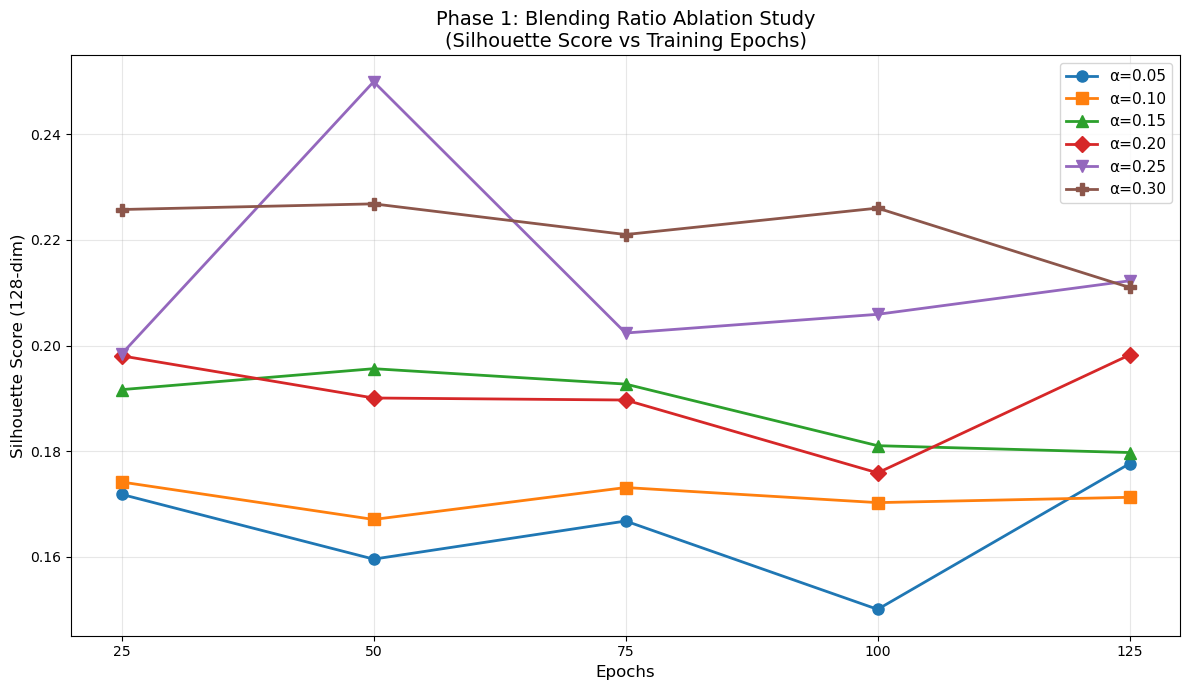


Alpha           Epoch 25    Epoch 50    Epoch 75   Epoch 100   Epoch 125  Best Score    Best Epoch
α=0.05            0.1718      0.1595      0.1668      0.1500      0.1776      0.1776     Epoch 125
α=0.10            0.1742      0.1671      0.1731      0.1702      0.1713      0.1742      Epoch 25
α=0.15            0.1916      0.1956      0.1927      0.1810      0.1797      0.1956      Epoch 50
α=0.20            0.1980      0.1901      0.1897      0.1759      0.1982      0.1982     Epoch 125
α=0.25            0.1984      0.2500      0.2024      0.2059      0.2123      0.2500      Epoch 50
α=0.30            0.2258      0.2268      0.2210      0.2260      0.2110      0.2268      Epoch 50

>>> BEST ALPHA: α=0.25 with score 0.2500
>>> Use this in Phase 2 for final comparison against NST, Rotation, and Concat.


In [20]:
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def get_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for anchor, _, _ in dataloader:
            anchor = anchor.to(device)
            embeddings.append(model(anchor).cpu())
    return torch.cat(embeddings, dim=0).numpy()

# ==========================================
# PHASE 1: EVALUATE ALL ALPHA CHECKPOINTS
# ==========================================
ablation_scores = {}
epoch_list = sorted(next(iter(ablation_checkpoints.values())).keys())

for name, checkpoints in ablation_checkpoints.items():
    print(f"Evaluating {name}...")
    ablation_scores[name] = {}
    loader = make_loader(ablation_datasets[name], batch_size=16, seed=SEED)
    
    for epoch, state_dict in sorted(checkpoints.items()):
        model = EmbeddingNet().to(device)
        model.load_state_dict(state_dict)
        embeddings = get_embeddings(model, loader, device)
        
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        
        ablation_scores[name][epoch] = score
        print(f"  Epoch {epoch}: {score:.4f}")

# ==========================================
# LEARNING CURVE PLOT
# ==========================================
plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', 'P']

for idx, (name, scores) in enumerate(ablation_scores.items()):
    epochs = sorted(scores.keys())
    values = [scores[e] for e in epochs]
    plt.plot(epochs, values, 
             marker=markers[idx], color=colors[idx],
             linewidth=2, markersize=8, label=name)

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Silhouette Score (128-dim)", fontsize=12)
plt.title("Phase 1: Blending Ratio Ablation Study\n(Silhouette Score vs Training Epochs)", fontsize=14)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(epoch_list)
plt.tight_layout()
plt.show()

# ==========================================
# SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print(f"{'Alpha':<12}", end="")
for e in epoch_list:
    print(f"{'Epoch '+str(e):>12}", end="")
print(f"{'Best Score':>12}  {'Best Epoch':>12}")
print("="*80)

best_overall_name = None
best_overall_score = -1

for name, scores in ablation_scores.items():
    print(f"{name:<12}", end="")
    best_score = -1
    best_epoch = -1
    for e in epoch_list:
        s = scores[e]
        if s > best_score:
            best_score = s
            best_epoch = e
        print(f"{s:>12.4f}", end="")
    print(f"{best_score:>12.4f}  {'Epoch '+str(best_epoch):>12}")
    
    if best_score > best_overall_score:
        best_overall_score = best_score
        best_overall_name = name

print("="*80)
print(f"\n>>> BEST ALPHA: {best_overall_name} with score {best_overall_score:.4f}")
print(f">>> Use this in Phase 2 for final comparison against NST, Rotation, and Concat.")

## Phase 2: Final Comparison
Compare the best blending ratio (α=0.25) against NST, Rotation, and Concat baselines under identical conditions.

In [21]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TripletDatasetPhase2(Dataset):
    """Unified TripletDataset for Phase 2 — handles all augmentation types."""
    def __init__(self, positive_dir, anchor_dir, negative_dir, suffix, transform=None, neg_seed=42):
        self.positive_dir = os.path.normpath(positive_dir)
        self.anchor_dir = os.path.normpath(anchor_dir)
        self.negative_dir = os.path.normpath(negative_dir)
        self.transform = transform
        self.suffix = suffix

        # Load and verify positive-anchor pairs
        self.positive_images = []
        self.anchor_images = []
        for f in sorted(os.listdir(self.positive_dir)):
            if f.endswith(suffix):
                anchor_name = f.replace(suffix, '.jpg')
                pos_path = os.path.join(self.positive_dir, f)
                anc_path = os.path.join(self.anchor_dir, anchor_name)
                try:
                    with Image.open(pos_path) as img:
                        img.verify()
                    with Image.open(anc_path) as img:
                        img.verify()
                    self.positive_images.append(f)
                    self.anchor_images.append(anchor_name)
                except (IOError, OSError) as e:
                    print(f"Skipping: {f} - {e}")

        # Load negative images
        self.negative_images = []
        for f in sorted(os.listdir(self.negative_dir)):
            if f.endswith('.png'):
                try:
                    with Image.open(os.path.join(self.negative_dir, f)) as img:
                        img.verify()
                    self.negative_images.append(f)
                except (IOError, OSError):
                    pass

        if not self.positive_images:
            raise RuntimeError(f"No valid images in {positive_dir}")

        # Fixed negative assignment — same seed across all branches
        rng = np.random.RandomState(neg_seed)
        self.neg_indices = rng.randint(0, len(self.negative_images), size=len(self.positive_images))
        print(f"  {positive_dir}: {len(self.positive_images)} pairs loaded")

    def __len__(self):
        return len(self.positive_images)

    def __getitem__(self, idx):
        pos_path = os.path.join(self.positive_dir, self.positive_images[idx])
        anc_path = os.path.join(self.anchor_dir, self.anchor_images[idx])
        neg_path = os.path.join(self.negative_dir, self.negative_images[self.neg_indices[idx]])
        
        anchor = Image.open(anc_path).convert('RGB')
        positive = Image.open(pos_path).convert('RGB')
        negative = Image.open(neg_path).convert('RGB')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Phase 2 datasets: Best alpha vs baselines
print("Loading Phase 2 datasets...\n")
phase2_datasets = {
    "NST": TripletDatasetPhase2(
        './nst_output', './messidor', './negative_images', '_nst.jpg', transform, neg_seed=42),
    "Rotation": TripletDatasetPhase2(
        './rot_output', './messidor', './negative_images', '_rot90.jpg', transform, neg_seed=42),
    "Concat": TripletDatasetPhase2(
        './result/concatenated', './messidor', './negative_images', '_concat.jpg', transform, neg_seed=42),
    "NST+FB (α=0.25)": TripletDatasetPhase2(
        './result/blended_025', './messidor', './negative_images', '_blended.jpg', transform, neg_seed=42),
}

print(f"\n{len(phase2_datasets)} Phase 2 datasets loaded.")

Loading Phase 2 datasets...

  ./nst_output: 382 pairs loaded
  ./rot_output: 382 pairs loaded
  ./result/concatenated: 382 pairs loaded
  ./result/blended_025: 382 pairs loaded

4 Phase 2 datasets loaded.


In [23]:
# ==========================================
# PHASE 2: TRAIN — Best Alpha vs Baselines
# ==========================================
phase2_checkpoints = {}
phase2_models = {}

for name, ds in phase2_datasets.items():
    print(f"\n{'='*60}")
    print(f"=== Training {name} ({TOTAL_EPOCHS} epochs) ===")
    print(f"{'='*60}")
    
    seed_everything(SEED)
    loader = make_loader(ds, batch_size=16, seed=SEED)
    model = EmbeddingNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    loss_fn = TripletLoss(margin=1.0)
    
    checkpoints = train_with_checkpoints(model, loader, optimizer, loss_fn, TOTAL_EPOCHS, CHECKPOINT_EVERY)
    phase2_checkpoints[name] = checkpoints
    phase2_models[name] = model

print(f"\n{'='*60}")
print("Phase 2 training complete!")
print(f"{'='*60}")


=== Training NST (125 epochs) ===


Epoch 1/125: 100%|█████████████████████████████████████████████████████████| 24/24 [00:15<00:00,  1.59it/s, loss=0.412]


Epoch 1 - Avg Loss: 0.5223


Epoch 2/125: 100%|█████████████████████████████████████████████████████████| 24/24 [00:25<00:00,  1.06s/it, loss=0.127]


Epoch 2 - Avg Loss: 0.1681


...

Epoch 123 - Avg Loss: 0.0032


Epoch 124/125: 100%|██████████████████████████████████████████████████████| 24/24 [00:30<00:00,  1.26s/it, loss=0.0337]


Epoch 124 - Avg Loss: 0.0022


Epoch 125/125: 100%|█████████████████████████████████████████████████████| 24/24 [00:30<00:00,  1.26s/it, loss=0.00948]

Epoch 125 - Avg Loss: 0.0031
  >> Checkpoint saved at epoch 125

Phase 2 training complete!


Evaluating NST...


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 25: 0.2130


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 50: 0.1769


...

  Epoch 75: 0.2131


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 100: 0.2200


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  Epoch 125: 0.1816


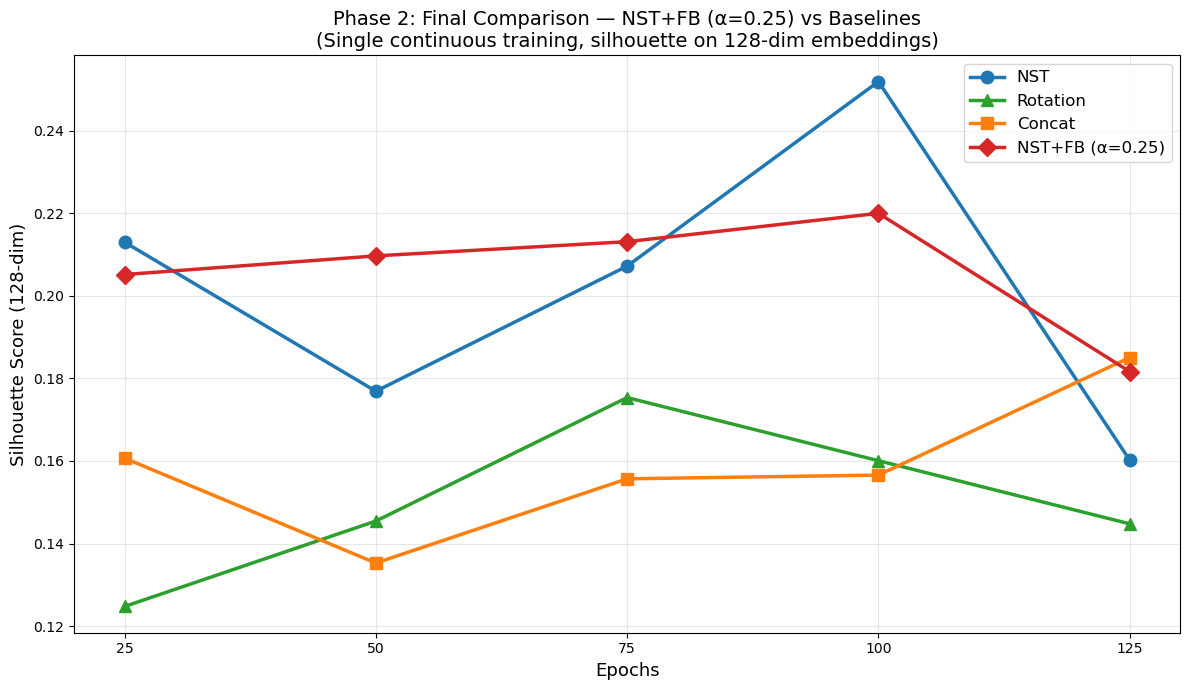


Method                  Epoch 25    Epoch 50    Epoch 75   Epoch 100   Epoch 125  Best Score    Best Epoch
NST                       0.2130      0.1769      0.2072      0.2519      0.1602      0.2519     Epoch 100
Rotation                  0.1248      0.1454      0.1754      0.1601      0.1448      0.1754      Epoch 75
Concat                    0.1607      0.1353      0.1557      0.1566      0.1851      0.1851     Epoch 125
NST+FB (α=0.25)           0.2052      0.2097      0.2131      0.2200      0.1816      0.2200     Epoch 100

>>> WINNER: NST with score 0.2519


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarnin

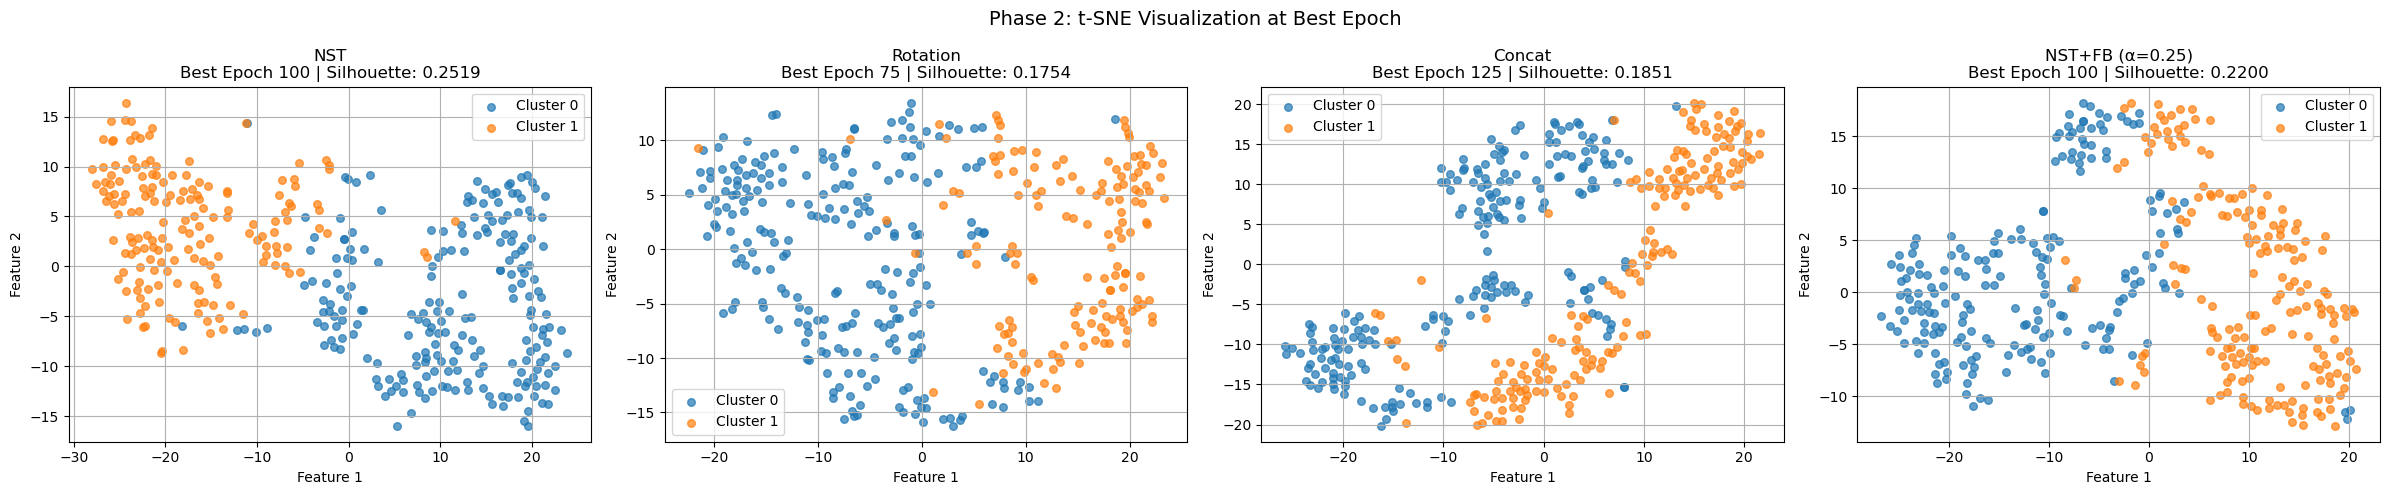

In [24]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================================
# PHASE 2: EVALUATE ALL CHECKPOINTS
# ==========================================
phase2_scores = {}
epoch_list = sorted(next(iter(phase2_checkpoints.values())).keys())

for name, checkpoints in phase2_checkpoints.items():
    print(f"Evaluating {name}...")
    phase2_scores[name] = {}
    loader = make_loader(phase2_datasets[name], batch_size=16, seed=SEED)
    
    for epoch, state_dict in sorted(checkpoints.items()):
        model = EmbeddingNet().to(device)
        model.load_state_dict(state_dict)
        embeddings = get_embeddings(model, loader, device)
        
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        
        phase2_scores[name][epoch] = score
        print(f"  Epoch {epoch}: {score:.4f}")

# ==========================================
# LEARNING CURVE PLOT
# ==========================================
plt.figure(figsize=(12, 7))
colors = {'NST': '#1f77b4', 'Rotation': '#2ca02c', 'Concat': '#ff7f0e', 'NST+FB (α=0.25)': '#d62728'}
markers = {'NST': 'o', 'Rotation': '^', 'Concat': 's', 'NST+FB (α=0.25)': 'D'}

for name, scores in phase2_scores.items():
    epochs = sorted(scores.keys())
    values = [scores[e] for e in epochs]
    plt.plot(epochs, values,
             marker=markers.get(name, 'o'), color=colors.get(name, 'black'),
             linewidth=2.5, markersize=9, label=name)

plt.xlabel("Epochs", fontsize=13)
plt.ylabel("Silhouette Score (128-dim)", fontsize=13)
plt.title("Phase 2: Final Comparison — NST+FB (α=0.25) vs Baselines\n(Single continuous training, silhouette on 128-dim embeddings)", fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(epoch_list)
plt.tight_layout()
plt.show()

# ==========================================
# SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print(f"{'Method':<20}", end="")
for e in epoch_list:
    print(f"{'Epoch '+str(e):>12}", end="")
print(f"{'Best Score':>12}  {'Best Epoch':>12}")
print("="*80)

best_method = None
best_overall = -1

for name, scores in phase2_scores.items():
    print(f"{name:<20}", end="")
    best_score = -1
    best_epoch = -1
    for e in epoch_list:
        s = scores[e]
        if s > best_score:
            best_score = s
            best_epoch = e
        print(f"{s:>12.4f}", end="")
    print(f"{best_score:>12.4f}  {'Epoch '+str(best_epoch):>12}")
    
    if best_score > best_overall:
        best_overall = best_score
        best_method = name

print("="*80)
print(f"\n>>> WINNER: {best_method} with score {best_overall:.4f}")

# ==========================================
# t-SNE VISUALIZATION AT BEST EPOCH
# ==========================================
n = len(phase2_scores)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

for idx, (name, scores) in enumerate(phase2_scores.items()):
    best_epoch = max(scores, key=scores.get)
    best_score = scores[best_epoch]
    
    model = EmbeddingNet().to(device)
    model.load_state_dict(phase2_checkpoints[name][best_epoch])
    loader = make_loader(phase2_datasets[name], batch_size=16, seed=SEED)
    embeddings = get_embeddings(model, loader, device)
    
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)
    
    ax = axes[idx] if n > 1 else axes
    for label in range(2):
        mask = labels == label
        ax.scatter(reduced[mask, 0], reduced[mask, 1],
                  label=f'Cluster {label}', alpha=0.7, s=30)
    ax.set_title(f"{name}\nBest Epoch {best_epoch} | Silhouette: {best_score:.4f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    ax.grid(True)

plt.suptitle("Phase 2: t-SNE Visualization at Best Epoch", fontsize=14)
plt.tight_layout()
plt.show()

## Categorize Messidor-2 Images by DR Grade
Sort images into 5 folders (Grade 0-4) using the diagnosis labels from `messidor_data.csv`.

In [1]:
import os
import csv
import shutil

# Paths
csv_path = './Messidor_Original/messidor_data.csv'
source_dir = './Messidor_Original/messidor-2'
output_base = './Messidor_Classified'

# DR Grade descriptions
grade_names = {
    0: 'Grade_0_No_DR',
    1: 'Grade_1_Mild',
    2: 'Grade_2_Moderate',
    3: 'Grade_3_Severe',
    4: 'Grade_4_Proliferative'
}

# Create output folders
for grade, folder_name in grade_names.items():
    os.makedirs(os.path.join(output_base, folder_name), exist_ok=True)

# Read CSV and copy images to corresponding grade folders
counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
missing = 0

with open(csv_path, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        id_code = row['id_code'].strip()
        diagnosis = int(row['diagnosis'].strip())
        
        src_path = os.path.join(source_dir, id_code)
        dst_folder = os.path.join(output_base, grade_names[diagnosis])
        dst_path = os.path.join(dst_folder, id_code)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
            counts[diagnosis] += 1
        else:
            missing += 1

# Print summary
print("=" * 50)
print("MESSIDOR-2 CLASSIFICATION SUMMARY")
print("=" * 50)
total = sum(counts.values())
for grade in sorted(counts.keys()):
    pct = (counts[grade] / total * 100) if total > 0 else 0
    print(f"  {grade_names[grade]:<30} : {counts[grade]:>5} images ({pct:.1f}%)")
print("-" * 50)
print(f"  {'Total classified':<30} : {total:>5} images")
if missing > 0:
    print(f"  {'Missing from source':<30} : {missing:>5} images")
print("=" * 50)
print(f"\nOutput directory: {os.path.abspath(output_base)}")

MESSIDOR-2 CLASSIFICATION SUMMARY
  Grade_0_No_DR                  :  1017 images (58.3%)
  Grade_1_Mild                   :   270 images (15.5%)
  Grade_2_Moderate               :   347 images (19.9%)
  Grade_3_Severe                 :    75 images (4.3%)
  Grade_4_Proliferative          :    35 images (2.0%)
--------------------------------------------------
  Total classified               :  1744 images

Output directory: C:\Users\USER\Desktop\beproject\Messidor_Classified


In [2]:
import os
import csv
from PIL import Image

output_base = './Messidor_Classified'

grade_folders = [
    'Grade_0_No_DR',
    'Grade_1_Mild',
    'Grade_2_Moderate',
    'Grade_3_Severe',
    'Grade_4_Proliferative'
]

mapping_records = []

for folder_name in grade_folders:
    folder_path = os.path.join(output_base, folder_name)
    if not os.path.exists(folder_path):
        print(f"Skipping {folder_name} — folder not found")
        continue
    
    # Get all PNG images, sorted for consistent ordering
    png_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.png')])
    
    # Rename: convert PNG → JPG with c1.jpg, c2.jpg, ... naming
    for idx, original_name in enumerate(png_files, start=1):
        src_path = os.path.join(folder_path, original_name)
        new_name = f"c{idx}.jpg"
        dst_path = os.path.join(folder_path, new_name)
        
        # Open PNG, save as JPG
        img = Image.open(src_path).convert('RGB')
        img.save(dst_path, 'JPEG', quality=95)
        
        # Remove original PNG
        os.remove(src_path)
        
        mapping_records.append((folder_name, original_name, new_name))
    
    print(f"  {folder_name}: {len(png_files)} images → c1.jpg to c{len(png_files)}.jpg")

# Save mapping CSV for reference
mapping_path = os.path.join(output_base, 'image_mapping.csv')
with open(mapping_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['folder', 'original_name', 'new_name'])
    writer.writerows(mapping_records)

print(f"\nDone! Mapping saved to: {mapping_path}")
print("All images renamed to c1.jpg, c2.jpg, ... format (JPG)")

  Grade_0_No_DR: 468 images → c1.jpg to c468.jpg
  Grade_1_Mild: 207 images → c1.jpg to c207.jpg
  Grade_2_Moderate: 290 images → c1.jpg to c290.jpg
  Grade_3_Severe: 71 images → c1.jpg to c71.jpg
  Grade_4_Proliferative: 21 images → c1.jpg to c21.jpg

Done! Mapping saved to: ./Messidor_Classified\image_mapping.csv
All images renamed to c1.jpg, c2.jpg, ... format (JPG)


In [4]:
pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   --- ------------------------------------ 3.7/40.2 MB 42.6 MB/s eta 0:00:01
   ---------------- ----------------------- 16.3/40.2 MB 56.8 MB/s eta 0:00:01
   --------------------------- ------------ 28.0/40.2 MB 56.2 MB/s eta 0:00:01
   ---------------------------------------  39.8/40.2 MB 56.2 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 55.8 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 43.3 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
import cv2
import os
import csv
import numpy as np
from tqdm import tqdm

# ==========================================
# Color Histogram Matching for Classified Images
# ==========================================

class ColorDescriptor:
    def __init__(self, bins=(8, 8, 8)):
        self.bins = bins

    def describe(self, image):
        hist = cv2.calcHist([image], [0, 1, 2], None, self.bins, [0, 180, 0, 256, 0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        return hist.tolist()

def extract_features(dataset_path, output_csv):
    cd = ColorDescriptor()
    with open(output_csv, "w", newline='') as f:
        writer = csv.writer(f)
        for image_name in tqdm(sorted(os.listdir(dataset_path)), desc=f"Indexing {output_csv}"):
            if not image_name.endswith(('.jpg', '.png', '.jpeg')):
                continue
            image_path = os.path.join(dataset_path, image_name)
            image = cv2.imread(image_path)
            if image is None:
                continue
            features = cd.describe(image)
            writer.writerow([image_path] + features)

def chi2_distance(histA, histB, eps=1e-10):
    return 0.5 * np.sum([((a - b) ** 2) / (a + b + eps) for a, b in zip(histA, histB)])

def match_images(messidor_csv, ptrbynum_csv, output_file):
    matches = []
    
    # Load painters dataset into memory
    painters_data = []
    with open(ptrbynum_csv, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            painters_data.append((row[0], [float(x) for x in row[1:]]))
    
    with open(messidor_csv, 'r') as f:
        reader = csv.reader(f)
        for row in tqdm(reader, desc=f"Matching {messidor_csv}"):
            messidor_img = row[0]
            messidor_feat = [float(x) for x in row[1:]]
            
            best_score = float('inf')
            best_match = None
            
            for painter_img, painter_feat in painters_data:
                d = chi2_distance(messidor_feat, painter_feat)
                if d < best_score:
                    best_score = d
                    best_match = painter_img
                    
            matches.append((messidor_img, best_match))
    
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Messidor Image', 'Painter Match'])
        writer.writerows(matches)

# ==========================================
# Run for each grade folder
# ==========================================
classified_base = './Messidor_Classified'
ptrbynum_dir = './painters_by_numbers'

grade_folders = [
    'Grade_0_No_DR',
    'Grade_1_Mild',
    'Grade_2_Moderate',
    'Grade_3_Severe',
    'Grade_4_Proliferative'
]

# Step 1: Extract painters histogram ONCE (reuse for all grades)
ptrbynum_csv = os.path.join(classified_base, 'ptrbynum_histogram.csv')
if not os.path.exists(ptrbynum_csv):
    print("Extracting painters_by_numbers histograms (one-time)...")
    extract_features(ptrbynum_dir, ptrbynum_csv)
    print("Done!\n")
else:
    print(f"Using existing {ptrbynum_csv}\n")

# Step 2: For each grade, extract histograms and match
for folder_name in grade_folders:
    grade_dir = os.path.join(classified_base, folder_name)
    if not os.path.exists(grade_dir):
        print(f"Skipping {folder_name} — folder not found")
        continue
    
    # Count images
    img_count = len([f for f in os.listdir(grade_dir) if f.endswith('.jpg')])
    if img_count == 0:
        print(f"Skipping {folder_name} — no images")
        continue
    
    print(f"\n{'='*50}")
    print(f"Processing {folder_name} ({img_count} images)")
    print(f"{'='*50}")
    
    # Extract histograms
    histogram_csv = os.path.join(classified_base, f'{folder_name}_histogram.csv')
    extract_features(grade_dir, histogram_csv)
    
    # Match to painters
    matches_csv = os.path.join(classified_base, f'{folder_name}_matches.csv')
    match_images(histogram_csv, ptrbynum_csv, matches_csv)
    
    print(f"  Histogram: {histogram_csv}")
    print(f"  Matches:   {matches_csv}")

print(f"\n{'='*50}")
print("All grades processed!")
print(f"{'='*50}")
print(f"\nOutput files in: {os.path.abspath(classified_base)}/")
for folder_name in grade_folders:
    print(f"  {folder_name}_histogram.csv")
    print(f"  {folder_name}_matches.csv")

Extracting painters_by_numbers histograms (one-time)...


Indexing ./Messidor_Classified\ptrbynum_histogram.csv: 100%|███████████████████████████████████████████████████████████| 8476/8476 [05:03<00:00, 27.89it/s]


Done!


Processing Grade_0_No_DR (468 images)


Indexing ./Messidor_Classified\Grade_0_No_DR_histogram.csv: 100%|█████████████████████████████████████████████████████| 1017/1017 [00:01<00:00, 732.08it/s]
Matching ./Messidor_Classified\Grade_0_No_DR_histogram.csv: 468it [08:37,  1.11s/it]


  Histogram: ./Messidor_Classified\Grade_0_No_DR_histogram.csv
  Matches:   ./Messidor_Classified\Grade_0_No_DR_matches.csv

Processing Grade_1_Mild (207 images)


...

  Histogram: ./Messidor_Classified\Grade_2_Moderate_histogram.csv
  Matches:   ./Messidor_Classified\Grade_2_Moderate_matches.csv

Processing Grade_3_Severe (71 images)


Indexing ./Messidor_Classified\Grade_3_Severe_histogram.csv: 100%|████████████████████████████████████████████████████████| 75/75 [00:00<00:00, 355.42it/s]
Matching ./Messidor_Classified\Grade_3_Severe_histogram.csv: 71it [01:08,  1.04it/s]


  Histogram: ./Messidor_Classified\Grade_3_Severe_histogram.csv
  Matches:   ./Messidor_Classified\Grade_3_Severe_matches.csv

Processing Grade_4_Proliferative (21 images)


Indexing ./Messidor_Classified\Grade_4_Proliferative_histogram.csv: 100%|█████████████████████████████████████████████████| 35/35 [00:00<00:00, 638.79it/s]
Matching ./Messidor_Classified\Grade_4_Proliferative_histogram.csv: 21it [00:21,  1.00s/it]

  Histogram: ./Messidor_Classified\Grade_4_Proliferative_histogram.csv
  Matches:   ./Messidor_Classified\Grade_4_Proliferative_matches.csv

All grades processed!

Output files in: C:\Users\USER\Desktop\beproject\Messidor_Classified/
  Grade_0_No_DR_histogram.csv
  Grade_0_No_DR_matches.csv
  Grade_1_Mild_histogram.csv
  Grade_1_Mild_matches.csv
  Grade_2_Moderate_histogram.csv
  Grade_2_Moderate_matches.csv
  Grade_3_Severe_histogram.csv
  Grade_3_Severe_matches.csv
  Grade_4_Proliferative_histogram.csv
  Grade_4_Proliferative_matches.csv


## NST Pipeline for Classified Images
Run Neural Style Transfer for each DR grade using the matched painter images. Ensure the NST function cells above (Vgg19, neural_style_transfer) have been run first.

In [1]:
#THIS IS NEURAL STYLE TRANSFER

# 📦 Imports
import os
import cv2 as cv
import numpy as np
import torch
from torch import nn
from torchvision import models, transforms
from torch.optim import LBFGS
from torch.autograd import Variable
import pandas as pd

# 🧠 Constants
IMAGENET_MEAN_255 = [123.675, 116.28, 103.53]
IMAGENET_STD_NEUTRAL = [1, 1, 1]

In [2]:
def load_image(img_path, target_shape=None):
    if not os.path.exists(img_path):
        raise Exception(f'Path not found: {img_path}')
    img = cv.imread(img_path)[:, :, ::-1]  # BGR to RGB
    if target_shape is not None:
        if isinstance(target_shape, int) and target_shape != -1:
            h, w = img.shape[:2]
            new_h = target_shape
            new_w = int(w * (new_h / h))
            img = cv.resize(img, (new_w, new_h), interpolation=cv.INTER_CUBIC)
        else:
            img = cv.resize(img, (target_shape[1], target_shape[0]), interpolation=cv.INTER_CUBIC)
    img = img.astype(np.float32) / 255.0
    return img
    
def prepare_img(img_path, target_shape, device):
    img = load_image(img_path, target_shape=target_shape)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.mul(255)),
        transforms.Normalize(mean=IMAGENET_MEAN_255, std=IMAGENET_STD_NEUTRAL)
    ])
    img = transform(img).to(device).unsqueeze(0)
    return img

def save_image(img_tensor, path):
    img = img_tensor.squeeze().cpu().detach().numpy()
    img = np.moveaxis(img, 0, 2)
    img += np.array(IMAGENET_MEAN_255).reshape((1, 1, 3))
    img = np.clip(img, 0, 255).astype('uint8')
    cv.imwrite(path, img[:, :, ::-1])  # RGB to BGR

def gram_matrix(x, normalize=True):
    (b, ch, h, w) = x.size()
    features = x.view(b, ch, w * h)
    features_t = features.transpose(1, 2)
    gram = features.bmm(features_t)
    if normalize:
        gram /= ch * h * w
    return gram

def total_variation(y):
    return torch.sum(torch.abs(y[:, :, :, :-1] - y[:, :, :, 1:])) + torch.sum(torch.abs(y[:, :, :-1, :] - y[:, :, 1:, :]))


In [3]:
import torch
import torch.nn as nn

In [4]:
# 🧠 VGG Feature Extractor

class Vgg19(nn.Module):
    def __init__(self, requires_grad=False):
        super(Vgg19, self).__init__()
        vgg_pretrained_features = models.vgg19(weights='VGG19_Weights.DEFAULT').features
        self.slice = nn.ModuleList()
        self.layer_names = []
        count = 0
        for layer in vgg_pretrained_features:
            if isinstance(layer, nn.ReLU):
                layer = nn.ReLU(inplace=False)
            self.slice.append(layer)
            self.layer_names.append(f'layer_{count}')
            count += 1
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False
        self.content_feature_maps_index = 21
        self.style_feature_maps_indices = [0, 5, 10, 19, 28]

    def forward(self, x):
        features = []
        for i, layer in enumerate(self.slice):
            x = layer(x)
            if i in self.style_feature_maps_indices or i == self.content_feature_maps_index:
                features.append(x)
        return features

# 🎨 NST Core Logic

def build_loss(model, optimizing_img, targets, content_idx, style_indices, config):
    content_target, style_targets = targets
    features = model(optimizing_img)

    content_pred = features[style_indices.index(content_idx)]
    content_loss = nn.MSELoss()(content_pred.squeeze(), content_target)

    style_loss = 0.0
    for gt, pred in zip(style_targets, [gram_matrix(f) for i, f in enumerate(features) if i in style_indices]):
        style_loss += nn.MSELoss()(gt, pred)

    style_loss /= len(style_targets)
    tv_loss = total_variation(optimizing_img)

    total = config['content_weight'] * content_loss + config['style_weight'] * style_loss + config['tv_weight'] * tv_loss
    return total, content_loss, style_loss, tv_loss

def neural_style_transfer(config):
    content_img_path = os.path.join(config['content_images_dir'], config['content_img_name'])
    style_img_path = os.path.join(config['style_images_dir'], config['style_img_name'])

    out_img_name = f"{os.path.splitext(config['content_img_name'])[0]}_nst.jpg"
    dump_path = config['output_img_dir']
    os.makedirs(dump_path, exist_ok=True)

    # Assuming final_output_img is the result from NST
    # final_output_img = ...  # <-- Your NST output
    # final_output_img.save(os.path.join(dump_path, out_img_name))
    print(f"✅ Saved NST image to {os.path.join(dump_path, out_img_name)}")


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    content_img = prepare_img(content_img_path, config['height'], device)
    style_img = prepare_img(style_img_path, config['height'], device)
    init_img = content_img.clone()

    model = Vgg19().to(device).eval()

    # Extract features
    content_and_style_feats = model(content_img)
    style_feats = model(style_img)

    # Last feature is content, others are style
    content_target = content_and_style_feats[-1].squeeze()
    style_targets = [gram_matrix(feat) for feat in style_feats[:-1]]

    targets = (content_target, style_targets)
    optimizing_img = Variable(init_img.clone(), requires_grad=True)
    optimizer = LBFGS([optimizing_img], max_iter=300)

    iteration = [0]
    def closure():
        optimizer.zero_grad()
        feats = model(optimizing_img)
        content_feat = feats[-1]
        style_feats_out = feats[:-1]

        content_loss = nn.MSELoss()(content_feat.squeeze(), content_target)

        style_loss = 0.0
        for gt, pred in zip(style_targets, [gram_matrix(f) for f in style_feats_out]):
            style_loss += nn.MSELoss()(gt, pred)

        style_loss /= len(style_targets)
        tv_loss = total_variation(optimizing_img)

        total = config['content_weight'] * content_loss + config['style_weight'] * style_loss + config['tv_weight'] * tv_loss
        total.backward()

        if iteration[0] % 50 == 0:
            print(f"Iter {iteration[0]} | Total: {total.item():.2f} | Content: {content_loss.item():.2f} | Style: {style_loss.item():.2f} | TV: {tv_loss.item():.2f}")
        iteration[0] += 1
        return total

    optimizer.step(closure)

    final_img_path = os.path.join(dump_path, f"{os.path.splitext(config['content_img_name'])[0]}_nst.jpg")
    save_image(optimizing_img, final_img_path)
    print(f"✅ Saved to: {final_img_path}")


In [5]:
import os
import pandas as pd

# Base paths
classified_base = './Messidor_Classified'
painters_dir = './painters_by_numbers'

grade_folders = [
    'Grade_0_No_DR',
    'Grade_1_Mild',
    'Grade_2_Moderate',
    'Grade_3_Severe',
    'Grade_4_Proliferative'
]

for folder_name in grade_folders:
    grade_dir = os.path.join(classified_base, folder_name)
    matches_csv = os.path.join(classified_base, f'{folder_name}_matches.csv')
    nst_output_dir = os.path.join(classified_base, f'{folder_name}_nst')
    
    if not os.path.exists(matches_csv):
        print(f"Skipping {folder_name} — no matches file found")
        continue
    
    os.makedirs(nst_output_dir, exist_ok=True)
    
    matches = pd.read_csv(matches_csv)
    total = len(matches)
    
    print(f"\n{'='*60}")
    print(f"NST for {folder_name} ({total} images)")
    print(f"Output: {nst_output_dir}")
    print(f"{'='*60}")
    
    for idx, row in matches.iterrows():
        content_img = os.path.basename(row['Messidor Image'])
        style_img = os.path.basename(row['Painter Match'])
        
        # Skip if already generated
        out_name = f"{os.path.splitext(content_img)[0]}_nst.jpg"
        if os.path.exists(os.path.join(nst_output_dir, out_name)):
            print(f"  [{idx+1}/{total}] Skipping {content_img} — already exists")
            continue
        
        config = {
            'content_img_name': content_img,
            'style_img_name': style_img,
            'height': 400,
            'content_weight': 100000.0,
            'style_weight': 30000.0,
            'tv_weight': 1.0,
            'content_images_dir': grade_dir,
            'style_images_dir': painters_dir,
            'output_img_dir': nst_output_dir,
            'img_format': (4, '.jpg')
        }
        
        print(f"\n  [{idx+1}/{total}] {content_img} + {style_img}")
        try:
            neural_style_transfer(config)
        except Exception as e:
            print(f"  ERROR: {e} — skipping {content_img}")

    done = len([f for f in os.listdir(nst_output_dir) if f.endswith('_nst.jpg')])
    print(f"\n  Completed: {done}/{total} images")

print(f"\n{'='*60}")
print("NST pipeline complete for all grades!")
print(f"{'='*60}")
print("\nOutput folders:")
for folder_name in grade_folders:
    nst_dir = os.path.join(classified_base, f'{folder_name}_nst')
    if os.path.exists(nst_dir):
        count = len([f for f in os.listdir(nst_dir) if f.endswith('_nst.jpg')])
        print(f"  {nst_dir}/ — {count} images")


NST for Grade_0_No_DR (468 images)
Output: ./Messidor_Classified\Grade_0_No_DR_nst
  [1/468] Skipping c1.jpg — already exists
  [2/468] Skipping c10.jpg — already exists
  [3/468] Skipping c100.jpg — already exists
  [4/468] Skipping c101.jpg — already exists
  [5/468] Skipping c102.jpg — already exists
  [6/468] Skipping c103.jpg — already exists
  [7/468] Skipping c104.jpg — already exists
  [8/468] Skipping c105.jpg — already exists
  [9/468] Skipping c106.jpg — already exists
  [10/468] Skipping c107.jpg — already exists
  [11/468] Skipping c108.jpg — already exists
  [12/468] Skipping c109.jpg — already exists
  [13/468] Skipping c11.jpg — already exists
  [14/468] Skipping c110.jpg — already exists
  [15/468] Skipping c111.jpg — already exists
  [16/468] Skipping c112.jpg — already exists
  [17/468] Skipping c113.jpg — already exists
  [18/468] Skipping c114.jpg — already exists
  [19/468] Skipping c115.jpg — already exists
  [20/468] Skipping c116.jpg — already exists
  [21/468

In [1]:
# ==========================================
# DiffuseMix Augmentation for Classified Images
# ==========================================
# For each grade: Original + NST → Concatenated → Blend with Fractal (α=0.25)

import os
import random
import numpy as np
from PIL import Image

base_dir = './Messidor_Classified'

grade_folders = [
    'Grade_0_No_DR',
    'Grade_1_Mild',
    'Grade_2_Moderate',
    'Grade_3_Severe',
    'Grade_4_Proliferative'
]

ALPHA = 0.25  # Optimal blending ratio from Phase 1 ablation

# --- Load fractal pool from existing pipeline ---
fractal_pool_dir = './result/fractal'
fractal_paths = [os.path.join(fractal_pool_dir, f) 
                 for f in os.listdir(fractal_pool_dir) 
                 if f.endswith(('.jpg', '.png', '.jpeg'))]
fractal_imgs = [Image.open(p).convert('RGB').resize((256, 256)) for p in fractal_paths]
print(f"Loaded {len(fractal_imgs)} fractal images from pool\n")

# --- Utility functions (same as original DiffuseMix pipeline) ---

def combine_images(original_img, augmented_img, blend_width=20):
    """Concatenate original + NST with gradient blend transition."""
    width, height = original_img.size
    combine_choice = random.choice(['horizontal', 'vertical'])

    if combine_choice == 'vertical':
        mask = np.linspace(0, 1, blend_width).reshape(-1, 1)
        mask = np.tile(mask, (1, width))
        mask = np.vstack([
            np.zeros((height // 2 - blend_width // 2, width)),
            mask,
            np.ones((height // 2 - blend_width // 2 + blend_width % 2, width))
        ])
        mask = np.tile(mask[:, :, np.newaxis], (1, 1, 3))
    else:
        mask = np.linspace(0, 1, blend_width).reshape(1, -1)
        mask = np.tile(mask, (height, 1))
        mask = np.hstack([
            np.zeros((height, width // 2 - blend_width // 2)),
            mask,
            np.ones((height, width // 2 - blend_width // 2 + blend_width % 2))
        ])
        mask = np.tile(mask[:, :, np.newaxis], (1, 1, 3))

    original_array = np.array(original_img, dtype=np.float32) / 255.0
    augmented_array = np.array(augmented_img, dtype=np.float32) / 255.0

    blended_array = (1 - mask) * original_array + mask * augmented_array
    blended_array = np.clip(blended_array * 255, 0, 255).astype(np.uint8)

    return Image.fromarray(blended_array)


def blend_images_with_resize(base_img, overlay_img, alpha=0.25):
    """Blend concatenated image with fractal overlay."""
    overlay_img_resized = overlay_img.resize(base_img.size)
    base_array = np.array(base_img, dtype=np.float32)
    overlay_array = np.array(overlay_img_resized, dtype=np.float32)
    blended_array = (1 - alpha) * base_array + alpha * overlay_array
    blended_array = np.clip(blended_array, 0, 255).astype(np.uint8)
    return Image.fromarray(blended_array)


# --- Process each grade folder ---
random.seed(42)

summary = {}

for grade in grade_folders:
    orig_dir = os.path.join(base_dir, grade)
    nst_dir = os.path.join(base_dir, f"{grade}_nst")
    concat_dir = os.path.join(base_dir, f"{grade}_concatenated")
    fractal_out_dir = os.path.join(base_dir, f"{grade}_fractal")
    blended_dir = os.path.join(base_dir, f"{grade}_blended")

    os.makedirs(concat_dir, exist_ok=True)
    os.makedirs(fractal_out_dir, exist_ok=True)
    os.makedirs(blended_dir, exist_ok=True)

    # Get original images (c*.jpg pattern)
    orig_images = sorted(
        [f for f in os.listdir(orig_dir) if f.startswith('c') and f.endswith('.jpg')],
        key=lambda x: int(x[1:].split('.')[0])
    )

    count = 0
    skipped = 0

    for img_name in orig_images:
        base_name = os.path.splitext(img_name)[0]  # e.g., 'c1'
        nst_name = f"{base_name}_nst.jpg"
        nst_path = os.path.join(nst_dir, nst_name)

        if not os.path.exists(nst_path):
            skipped += 1
            continue

        # Load and resize to 256x256
        orig_img = Image.open(os.path.join(orig_dir, img_name)).convert('RGB').resize((256, 256))
        nst_img = Image.open(nst_path).convert('RGB').resize((256, 256))

        # Step 1: Concatenate (original + NST with gradient blend)
        concatenated = combine_images(orig_img, nst_img)
        concatenated.save(os.path.join(concat_dir, f"{base_name}_concat.jpg"))

        # Step 2: Select random fractal and save
        fractal_img = random.choice(fractal_imgs)
        fractal_img.save(os.path.join(fractal_out_dir, f"{base_name}_fractal.jpg"))

        # Step 3: Blend concatenated + fractal (alpha=0.25)
        blended = blend_images_with_resize(concatenated, fractal_img, alpha=ALPHA)
        blended.save(os.path.join(blended_dir, f"{base_name}_blended.jpg"))

        count += 1

    summary[grade] = {'processed': count, 'skipped': skipped}
    print(f"{grade}: {count} images processed, {skipped} skipped")

print(f"\nDiffuseMix augmentation complete for all grades (alpha={ALPHA})!")
print(f"\nOutput folders per grade:")
for grade in grade_folders:
    print(f"  {grade}_concatenated/  {grade}_fractal/  {grade}_blended/")
print(f"\nSummary: {sum(s['processed'] for s in summary.values())} total images augmented")

Loaded 382 fractal images from pool

Grade_0_No_DR: 468 images processed, 0 skipped
Grade_1_Mild: 207 images processed, 0 skipped
Grade_2_Moderate: 290 images processed, 0 skipped
Grade_3_Severe: 71 images processed, 0 skipped
Grade_4_Proliferative: 21 images processed, 0 skipped

DiffuseMix augmentation complete for all grades (alpha=0.25)!

Output folders per grade:
  Grade_0_No_DR_concatenated/  Grade_0_No_DR_fractal/  Grade_0_No_DR_blended/
  Grade_1_Mild_concatenated/  Grade_1_Mild_fractal/  Grade_1_Mild_blended/
  Grade_2_Moderate_concatenated/  Grade_2_Moderate_fractal/  Grade_2_Moderate_blended/
  Grade_3_Severe_concatenated/  Grade_3_Severe_fractal/  Grade_3_Severe_blended/
  Grade_4_Proliferative_concatenated/  Grade_4_Proliferative_fractal/  Grade_4_Proliferative_blended/

Summary: 1057 total images augmented


In [2]:
# ==========================================
# Supervised TripletDataset + Training Setup
# ==========================================
# Anchor: original image (Grade X)
# Positive: augmented image (same Grade X, same image)
# Negative: original image from DIFFERENT Grade Y
# Compare: NST vs Concat vs NST+FB(blended) augmentation

import os
import copy
import random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18
from tqdm import tqdm

# --- Supervised TripletDataset ---

class SupervisedTripletDataset(Dataset):
    """
    Grade-aware triplet dataset for supervised contrastive learning.
    - Anchor: original retinal image from Grade X
    - Positive: augmented version (NST/Concat/Blended) of the same image
    - Negative: original image from a different DR grade
    """
    def __init__(self, base_dir, grade_folders, aug_suffix, aug_folder_suffix, 
                 transform=None, neg_seed=42):
        self.transform = transform
        self.samples = []       # (anchor_path, positive_path, grade_idx)
        self.grade_originals = {}  # grade_idx -> [list of original image paths]

        for grade_idx, grade in enumerate(grade_folders):
            orig_dir = os.path.join(base_dir, grade)
            aug_dir = os.path.join(base_dir, f"{grade}{aug_folder_suffix}")

            grade_orig_paths = []

            for f in sorted(os.listdir(orig_dir)):
                if f.startswith('c') and f.endswith('.jpg'):
                    base_name = os.path.splitext(f)[0]
                    aug_name = f"{base_name}{aug_suffix}"
                    aug_path = os.path.join(aug_dir, aug_name)

                    if os.path.exists(aug_path):
                        anchor_path = os.path.join(orig_dir, f)
                        self.samples.append((anchor_path, aug_path, grade_idx))
                        grade_orig_paths.append(anchor_path)

            self.grade_originals[grade_idx] = grade_orig_paths

        # Pre-assign negatives deterministically (same seed = same negatives across branches)
        rng = np.random.RandomState(neg_seed)
        self.neg_paths = []
        all_grades = list(self.grade_originals.keys())

        for _, _, grade_idx in self.samples:
            other_grades = [g for g in all_grades if g != grade_idx]
            neg_grade = rng.choice(other_grades)
            neg_idx = rng.randint(0, len(self.grade_originals[neg_grade]))
            self.neg_paths.append(self.grade_originals[neg_grade][neg_idx])

        # Store grade labels for evaluation
        self.labels = [s[2] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        anchor_path, pos_path, _ = self.samples[idx]
        neg_path = self.neg_paths[idx]

        anchor = Image.open(anchor_path).convert('RGB')
        positive = Image.open(pos_path).convert('RGB')
        negative = Image.open(neg_path).convert('RGB')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative


# --- Model ---

class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)

    def forward(self, x):
        return F.normalize(self.resnet(x), p=2, dim=1)


class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        return F.relu(pos_dist - neg_dist + self.margin).mean()


# --- Config ---

base_dir = './Messidor_Classified'
grade_folders = [
    'Grade_0_No_DR',
    'Grade_1_Mild',
    'Grade_2_Moderate',
    'Grade_3_Severe',
    'Grade_4_Proliferative'
]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Loading supervised triplet datasets...\n")

supervised_datasets = {
    "NST": SupervisedTripletDataset(
        base_dir, grade_folders, '_nst.jpg', '_nst', transform, neg_seed=42),
    "Concat": SupervisedTripletDataset(
        base_dir, grade_folders, '_concat.jpg', '_concatenated', transform, neg_seed=42),
    "NST+FB": SupervisedTripletDataset(
        base_dir, grade_folders, '_blended.jpg', '_blended', transform, neg_seed=42),
}

print(f"\n{len(supervised_datasets)} supervised datasets loaded.")
for name, ds in supervised_datasets.items():
    print(f"  {name}: {len(ds)} triplets")

Loading supervised triplet datasets...


3 supervised datasets loaded.
  NST: 1057 triplets
  Concat: 1057 triplets
  NST+FB: 1057 triplets


In [3]:
# ==========================================
# Supervised Training Loop with Checkpoints
# ==========================================

import torch
import copy
import random
import numpy as np
from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def worker_init_fn(worker_id):
    np.random.seed(42 + worker_id)

def make_loader(dataset, batch_size=16, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True,
                      num_workers=0, pin_memory=torch.cuda.is_available(),
                      generator=g, worker_init_fn=worker_init_fn)

def train_with_checkpoints(model, loader, optimizer, loss_fn, total_epochs, checkpoint_every):
    model.train()
    checkpoints = {}
    for epoch in range(1, total_epochs + 1):
        total_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs}")
        for anchor, positive, negative in pbar:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(anchor), model(positive), model(negative))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch} - Avg Loss: {avg_loss:.4f}")
        if epoch % checkpoint_every == 0:
            checkpoints[epoch] = copy.deepcopy(model.state_dict())
            print(f"  >> Checkpoint saved at epoch {epoch}")
    return checkpoints

# --- Training config ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

TOTAL_EPOCHS = 125
CHECKPOINT_EVERY = 25
LR = 1e-4

all_supervised_checkpoints = {}

for name, dataset in supervised_datasets.items():
    print(f"\n{'='*60}")
    print(f"=== Training {name} Model ({TOTAL_EPOCHS} epochs) ===")
    print(f"{'='*60}")

    seed_everything(42)
    model = EmbeddingNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = TripletLoss(margin=1.0)
    loader = make_loader(dataset, batch_size=16, seed=42)

    checkpoints = train_with_checkpoints(
        model, loader, optimizer, loss_fn, TOTAL_EPOCHS, CHECKPOINT_EVERY
    )
    all_supervised_checkpoints[name] = checkpoints
    print(f"\n{name}: {len(checkpoints)} checkpoints saved")

print(f"\nAll supervised training complete!")

Using device: cuda

=== Training NST Model (125 epochs) ===


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/125: 100%|█████████████████████████████████████████████████████████| 67/67 [01:01<00:00,  1.09it/s, loss=0.966]


Epoch 1 - Avg Loss: 0.3296


Epoch 2/125: 100%|█████████████████████████████████████████████████████████████| 67/67 [01:00<00:00,  1.11it/s, loss=1]


Epoch 2 - Avg Loss: 0.1075


...

Epoch 123 - Avg Loss: 0.0124


Epoch 124/125: 100%|████████████████████████████████████████████████████████| 67/67 [00:57<00:00,  1.16it/s, loss=0.22]


Epoch 124 - Avg Loss: 0.0083


Epoch 125/125: 100%|███████████████████████████████████████████████████████| 67/67 [00:57<00:00,  1.17it/s, loss=0.598]

Epoch 125 - Avg Loss: 0.0172
  >> Checkpoint saved at epoch 125

NST+FB: 5 checkpoints saved

All supervised training complete!


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are

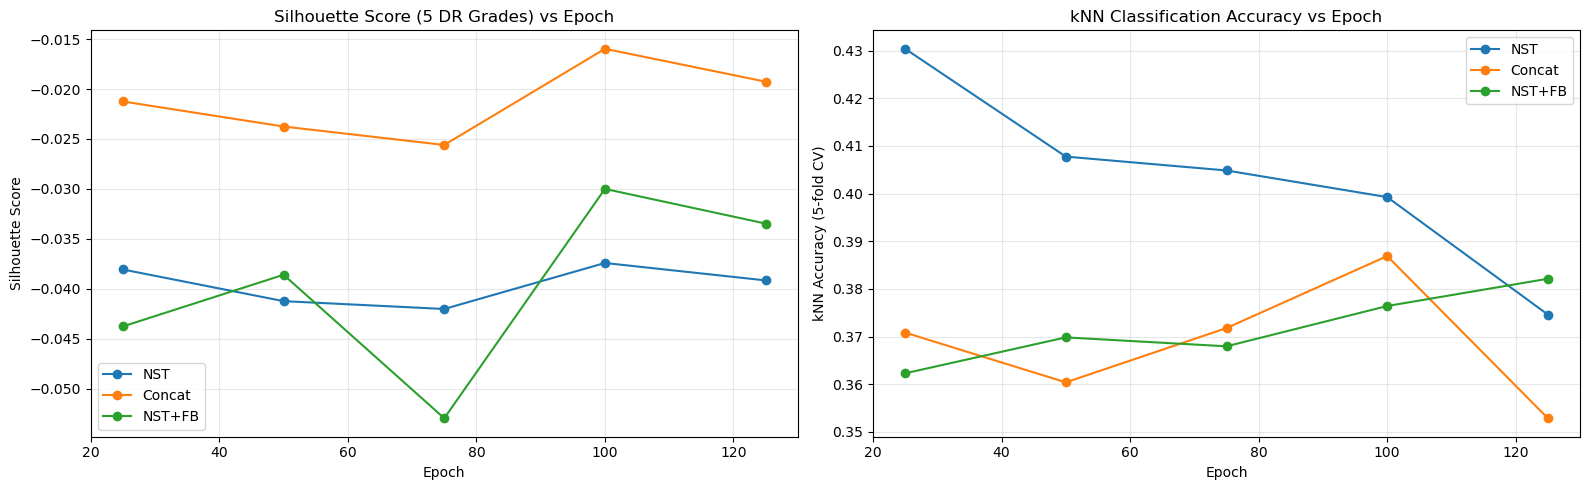


Method             Best Silhouette    @ Epoch    Best kNN Acc    @ Epoch
NST                        -0.0374        100          0.4304         25
Concat                     -0.0160        100          0.3869        100
NST+FB                     -0.0300        100          0.3821        125


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are

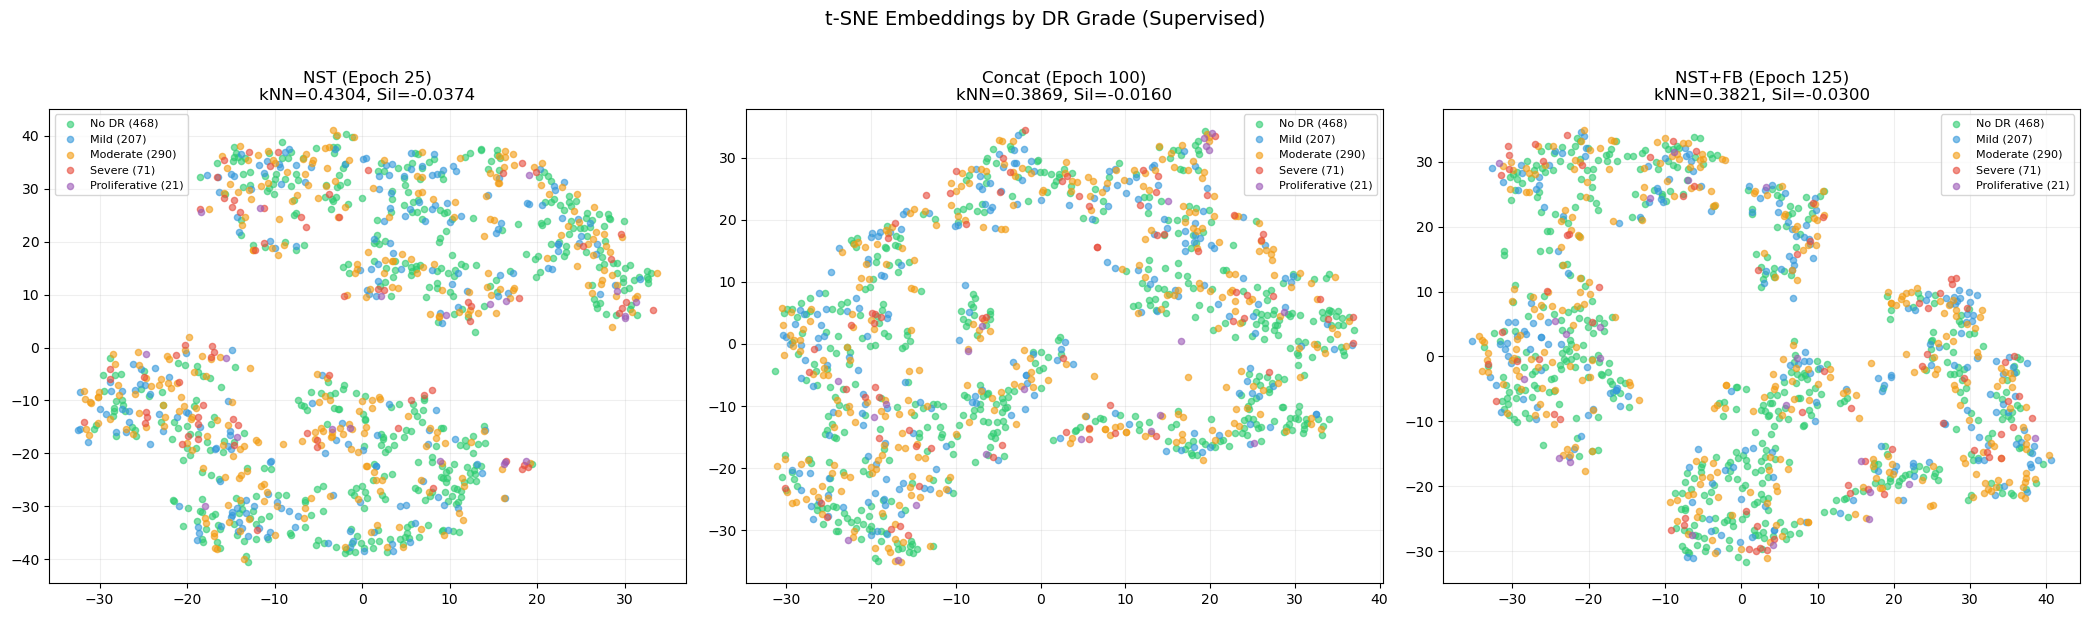

In [4]:
# ==========================================
# Supervised Evaluation: Silhouette + kNN Accuracy + t-SNE
# ==========================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.manifold import TSNE

def extract_embeddings_with_labels(model, dataset, device):
    """Extract 128-dim embeddings and grade labels from dataset."""
    model.eval()
    embeddings = []
    labels = []

    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

    with torch.no_grad():
        for anchor, _, _ in loader:
            anchor = anchor.to(device)
            emb = model(anchor)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    labels = np.array(dataset.labels)
    return embeddings, labels


def evaluate_supervised_checkpoints(all_checkpoints, datasets, device, n_grades=5):
    """Evaluate all checkpoints: silhouette score (5-grade), kNN accuracy, learning curves."""
    
    grade_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
    results = {}

    for name in all_checkpoints:
        checkpoints = all_checkpoints[name]
        dataset = datasets[name]
        epochs = sorted(checkpoints.keys())
        sil_scores = []
        knn_scores = []

        for epoch in epochs:
            model = EmbeddingNet().to(device)
            model.load_state_dict(checkpoints[epoch])

            embeddings, labels = extract_embeddings_with_labels(model, dataset, device)

            # Silhouette score on 128-dim embeddings (5 grades as true labels)
            sil = silhouette_score(embeddings, labels)
            sil_scores.append(sil)

            # k-NN classification accuracy (5-fold CV)
            knn = KNeighborsClassifier(n_neighbors=5)
            cv_scores = cross_val_score(knn, embeddings, labels, cv=5, scoring='accuracy')
            knn_scores.append(cv_scores.mean())

        results[name] = {
            'epochs': epochs,
            'silhouette': sil_scores,
            'knn_accuracy': knn_scores,
            'best_sil_epoch': epochs[np.argmax(sil_scores)],
            'best_sil': max(sil_scores),
            'best_knn_epoch': epochs[np.argmax(knn_scores)],
            'best_knn': max(knn_scores)
        }

    # --- Learning Curves ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Silhouette score plot
    for name, r in results.items():
        axes[0].plot(r['epochs'], r['silhouette'], 'o-', label=name)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('Silhouette Score (5 DR Grades) vs Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # kNN accuracy plot
    for name, r in results.items():
        axes[1].plot(r['epochs'], r['knn_accuracy'], 'o-', label=name)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('kNN Accuracy (5-fold CV)')
    axes[1].set_title('kNN Classification Accuracy vs Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Summary Table ---
    print("\n" + "="*80)
    print(f"{'Method':<15} {'Best Silhouette':>18} {'@ Epoch':>10} {'Best kNN Acc':>15} {'@ Epoch':>10}")
    print("="*80)
    for name, r in results.items():
        print(f"{name:<15} {r['best_sil']:>18.4f} {r['best_sil_epoch']:>10} "
              f"{r['best_knn']:>15.4f} {r['best_knn_epoch']:>10}")
    print("="*80)

    # --- t-SNE Visualization at best kNN epoch ---
    fig, axes = plt.subplots(1, len(results), figsize=(7*len(results), 6))
    if len(results) == 1:
        axes = [axes]

    colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']

    for ax, (name, r) in zip(axes, results.items()):
        best_epoch = r['best_knn_epoch']
        model = EmbeddingNet().to(device)
        model.load_state_dict(all_checkpoints[name][best_epoch])

        embeddings, labels = extract_embeddings_with_labels(model, datasets[name], device)

        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        emb_2d = tsne.fit_transform(embeddings)

        for grade_idx, grade_name in enumerate(grade_names):
            mask = labels == grade_idx
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=colors[grade_idx],
                      label=f'{grade_name} ({mask.sum()})', alpha=0.6, s=20)

        ax.set_title(f'{name} (Epoch {best_epoch})\nkNN={r["best_knn"]:.4f}, Sil={r["best_sil"]:.4f}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

    plt.suptitle('t-SNE Embeddings by DR Grade (Supervised)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return results

# --- Run evaluation ---
supervised_results = evaluate_supervised_checkpoints(
    all_supervised_checkpoints, supervised_datasets, device, n_grades=5
)